# **Case Study: Predicting Apartment Prices from Layout Characteristics**

**Note:** This notebook follows best practices to prevent data leakage by splitting data early and applying all preprocessing only on training data.

# **STAGE 1 : EXPLORATORY DATA ANALYSIS (EDA)**

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Settings
sns.set_style('darkgrid')
pd.set_option('display.max_columns', None)

In [2]:
# Load dataset
df_raw = pd.read_csv('data/case_data.csv', low_memory=False)

# Create a copy of the dataframe
df = df_raw.copy()

In [3]:
# Check the first few rows of the dataset
df.head()

,District,Address,Class,HouseNumber,Building,Plot,FloorsTotal,HandoverDate,Phase,BuildingType,InstallmentUntil,InstallmentMonths,Number,PIBNumber,LayoutType,Axis,Floor,Section,PropertyType,PropertyCategory,Apartments,Finishing,Status,ApartmentOption,Mortgage,Subsidies,Layout,CeilingHeight,TotalArea,AreaWithoutBalcony,LivingArea,KitchenArea,HallwayArea,BathroomArea,BalconyArea,PlotArea,PricePerMeter,TotalCost,Developer_encoded,Complex_encoded
0,МО Ленинский г.о.,"Сапроново д., Калиновая ул.",Комфорт,NaN,1,NaN,25,Сдан,1,Монолит,NaN,NaN,121,NaN,NaN,NaN,11,3,3 ккв,Многокв. дом,Нет,Чистовая,В продаже,Новостройка,Да,Нет,Да,2.8,76.1,74.1,43.7,12.2,13.5,"3,4с+1,3т","3,4л",0.0,266300.0,20265430.0,Developer58,Complex0
1,МО Ленинский г.о.,"Сапроново д., Калиновая ул.",Комфорт,NaN,1,NaN,25,Сдан,1,Монолит,NaN,NaN,144,NaN,NaN,NaN,16,3,3 ккв (Евро),Многокв. дом,Нет,Чистовая,В продаже,Новостройка,Да,Нет,Да,2.8,70.2,68.5,25.1,25.4,10.2,"3,4с+2т",3л,0.0,270900.0,19017180.0,Developer58,Complex0
2,МО Ленинский г.о.,"Сапроново д., Калиновая ул.",Комфорт,NaN,1,NaN,25,Сдан,1,Монолит,NaN,NaN,247,NaN,NaN,NaN,13,4,3 ккв,Многокв. дом,Нет,Чистовая,В продаже,Новостройка,Да,Нет,Да,2.8,77.9,75.8,43.9,13.4,13.6,"3,5с+1,4т","4,3б",0.0,264900.0,20635710.0,Developer58,Complex0
3,МО Ленинский г.о.,"Сапроново д., Калиновая ул.",Комфорт,NaN,1,NaN,25,Сдан,1,Монолит,NaN,NaN,153,NaN,NaN,NaN,19,3,3 ккв,Многокв. дом,Нет,Чистовая,В продаже,Новостройка,Да,Нет,Да,2.8,76.1,74.1,43.7,12.2,13.5,"3,4с+1,3т","3,4л",0.0,267300.0,20341530.0,Developer58,Complex0
4,МО Ленинский г.о.,"Сапроново д., Калиновая ул.",Комфорт,NaN,1,NaN,25,Сдан,1,Монолит,NaN,NaN,296,NaN,NaN,NaN,20,4,3 ккв,Многокв. дом,Нет,Чистовая,В продаже,Новостройка,Да,Нет,Да,2.8,77.9,75.8,43.9,13.4,13.6,"3,5с+1,4т","4,3б",0.0,266400.0,20752560.0,Developer58,Complex0


In [4]:
# Check the dataset information
from utils import check_data_information
check_data_information(df, cols=df.columns)

,Feature,Data Type,Null Values,Null Percentage,Zero Values,Zero Percentage,Negative Values,Negative Percentage,Empty Strings,Numeric in Object,Duplicated Values,Unique Values,Cardinality Ratio,Unique Sample
0,District,str,0,0.00,0,0.00,0,0.00,0,0,0,113,0.0019,"МО Ленинский г.о., Гольяново р-н, Молжаниновск..."
1,Address,str,0,0.00,0,0.00,0,0.00,0,0,0,323,0.0054,"Сапроново д., Калиновая ул., Москва г., Амурск..."
2,Class,str,0,0.00,0,0.00,0,0.00,0,0,0,4,0.0001,"Комфорт, Бизнес, Элит, Эконом"
3,HouseNumber,str,57660,97.22,0,0.00,0,0.00,0,830,0,29,0.0005,"nan, N, E, 1, 3"
4,Building,str,91,0.15,0,0.00,0,0.00,0,47827,0,507,0.0085,"1, 2, 4, 5, 3"
5,Plot,str,56249,94.84,0,0.00,0,0.00,0,967,0,49,0.0008,"nan, 1, 2, 3, 5"
6,FloorsTotal,int64,0,0.00,0,0.00,0,0.00,0,0,0,66,0.0011,"25, 24, 32, 15, 1"
7,HandoverDate,str,0,0.00,0,0.00,0,0.00,0,0,0,19,0.0003,"Сдан, 2026 г. 4 кв., 2027 г. 1 кв., 2027 г. 2 ..."
8,Phase,int64,0,0.00,0,0.00,0,0.00,0,0,0,28,0.0005,"1, 2, 3, 4, 5"
9,BuildingType,str,0,0.00,0,0.00,0,0.00,0,0,0,6,0.0001,"Монолит, Кирпич + Монолит, Панель, Монолит + П..."


In [5]:
# Checking shape of dataframe
print(f'Number of rows: {df.shape[0]}')
print(f'Number of columns: {df.shape[1]}')

Number of rows: 59310
Number of columns: 40


**Initial preprocessing steps for EDA:**

1. Drop columns with large percentage of missing values
2. Select relevant features based on requirements
3. Basic data exploration (univariate, bivariate analysis)

**Note:** We perform minimal cleaning here to understand the data. Heavy preprocessing (outlier removal, encoding, scaling) will be done AFTER splitting to prevent data leakage.

In [6]:
# Define features and target
target = 'TotalCost'

# Numerical features
numerical_features = [
    'FloorsTotal', 'Phase', 'Floor',
    'CeilingHeight', 'TotalArea', 'AreaWithoutBalcony',
    'LivingArea', 'KitchenArea', 'HallwayArea'
]

# Categorical features
categorical_features = [
    'Class', 'BuildingType', 'PropertyType',
    'PropertyCategory', 'Apartments', 'Finishing',
    'ApartmentOption', 'Mortgage', 'Subsidies', 'Layout'
]

print(f"Target: {target}")
print(f"Numerical features: {len(numerical_features)}")
print(f"Categorical features: {len(categorical_features)}")

# Filter out the columns based on findings in data information
df = df[numerical_features + categorical_features + [target]]

Target: TotalCost
Numerical features: 9
Categorical features: 10


## Univariate Analysis

**Purpose:** Understand distributions and basic statistics of features before splitting.

### Numerical Features

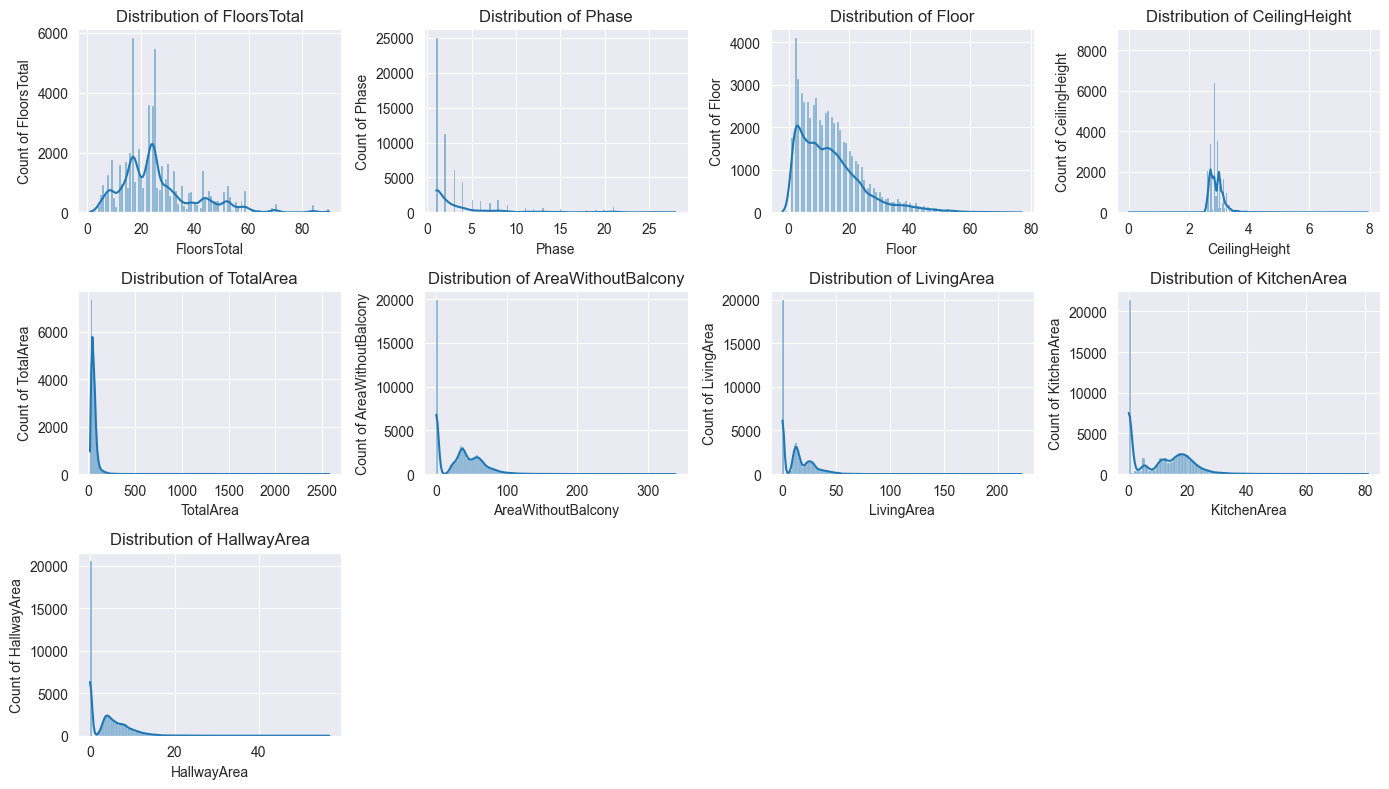

,Feature,overall_count,overall_mean,overall_std,overall_min,overall_25%,overall_50%,overall_75%,overall_max,overall_range,overall_IQR,overall_CV,overall_skewness,overall_kurtosis
0,FloorsTotal,59310.0,25.885854,13.887980,1.00,17.00,24.00,31.00,90.00,89.00,14.00,53.650846,1.232002,1.960952
1,Phase,59310.0,3.717012,4.694703,1.00,1.00,2.00,4.00,28.00,27.00,3.00,126.303131,2.660747,7.368455
2,Floor,59310.0,13.929253,10.700287,-2.00,6.00,12.00,19.00,77.00,79.00,13.00,76.818811,1.343070,2.273952
3,CeilingHeight,59310.0,2.942427,0.357592,0.00,2.73,2.85,3.02,7.95,7.95,0.29,12.152954,4.884894,47.053118
4,TotalArea,59310.0,60.166024,60.562978,16.88,37.90,52.00,68.60,2575.60,2558.72,30.70,100.659765,20.505493,594.172644
5,AreaWithoutBalcony,59310.0,33.657707,29.558089,0.00,0.00,35.50,54.90,339.50,339.50,54.90,87.819677,0.609190,0.802307
6,LivingArea,59310.0,14.337860,14.035079,0.00,0.00,12.70,23.50,222.40,222.40,23.50,97.888246,1.378936,6.546446
7,KitchenArea,59310.0,10.426443,9.606334,0.00,0.00,11.00,18.20,81.10,81.10,18.20,92.134339,0.474949,-0.174241
8,HallwayArea,59310.0,4.416951,4.226414,0.00,0.00,4.10,7.10,56.62,56.62,7.10,95.686220,1.050524,3.286216


In [7]:
# Checking the distribution and statistical summary of the numerical values
from utils import plot_dynamic_hisplots_kdeplots, describe_numerical_combined
plot_dynamic_hisplots_kdeplots(df=df, col_series=numerical_features, ncols=4, figsize=(14, 8))

# Display the overall statistics for numerical columns
numerical_summary = describe_numerical_combined(df, numerical_features)
display(numerical_summary)

### Categorical Features

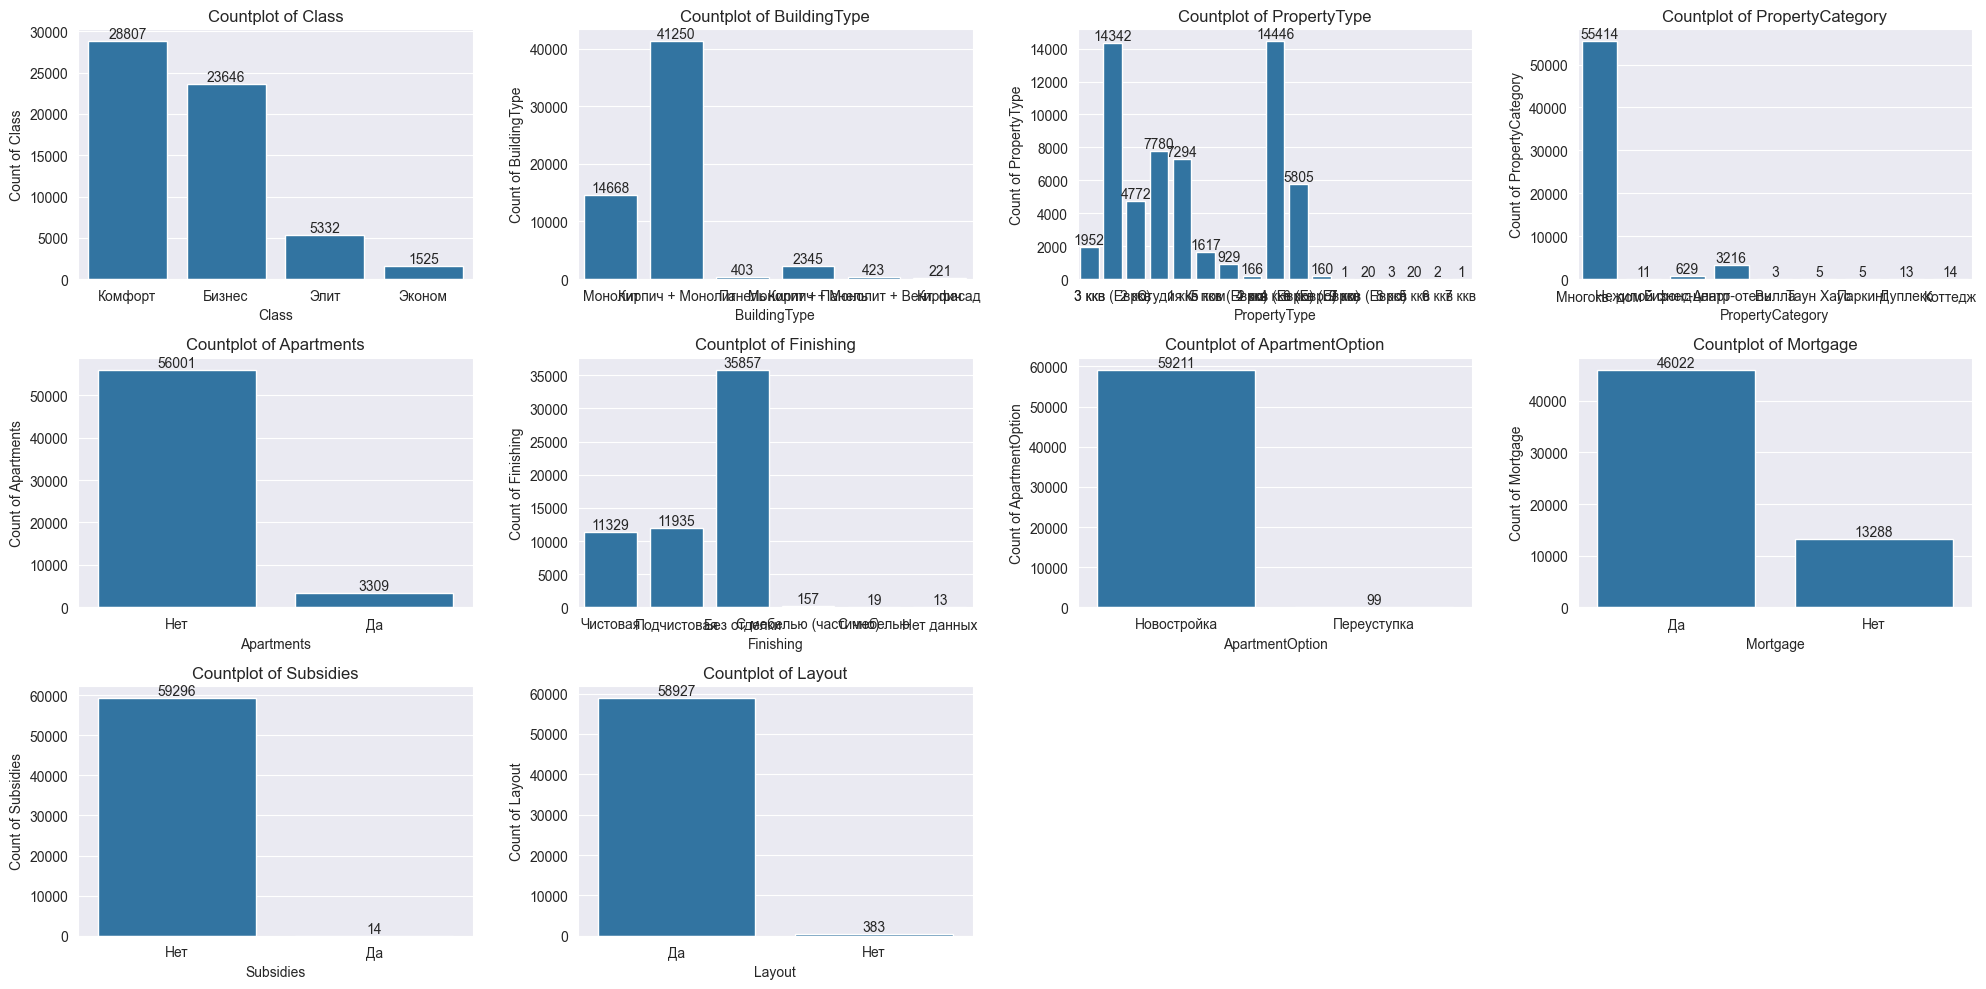

,Feature,overall_count,overall_unique,overall_top,overall_freq,overall_bottom,overall_freq_bottom,overall_top_percentage,overall_bottom_percentage,overall_n_categories
0,Class,59310,4,Комфорт,28807,Эконом,1525,48.57,2.57,4
1,BuildingType,59310,6,Кирпич + Монолит,41250,Кирпич,221,69.55,0.37,6
2,PropertyType,59310,17,2 ккв (Евро),14446,9 ккв,1,24.36,0.00,17
3,PropertyCategory,59310,9,Многокв. дом,55414,Вилла,3,93.43,0.01,9
4,Apartments,59310,2,Нет,56001,Да,3309,94.42,5.58,2
5,Finishing,59310,6,Без отделки,35857,Нет данных,13,60.46,0.02,6
6,ApartmentOption,59310,2,Новостройка,59211,Переуступка,99,99.83,0.17,2
7,Mortgage,59310,2,Да,46022,Нет,13288,77.60,22.40,2
8,Subsidies,59310,2,Нет,59296,Да,14,99.98,0.02,2
9,Layout,59310,2,Да,58927,Нет,383,99.35,0.65,2


In [8]:
# Checking the distribution and statistical summary of the categorical values
from utils import describe_categorical_combined, plot_dynamic_countplot

# Countplot function implementation
plot_dynamic_countplot(df=df, col_series=[col for col in categorical_features], ncols=4, figsize=(20, 10))

# Display the overall statistics for categorical columns
categorical_summary = describe_categorical_combined(df, categorical_features)
display(categorical_summary)

## Bivariate/Multivariate Analysis

<Figure size 1500x1500 with 0 Axes>

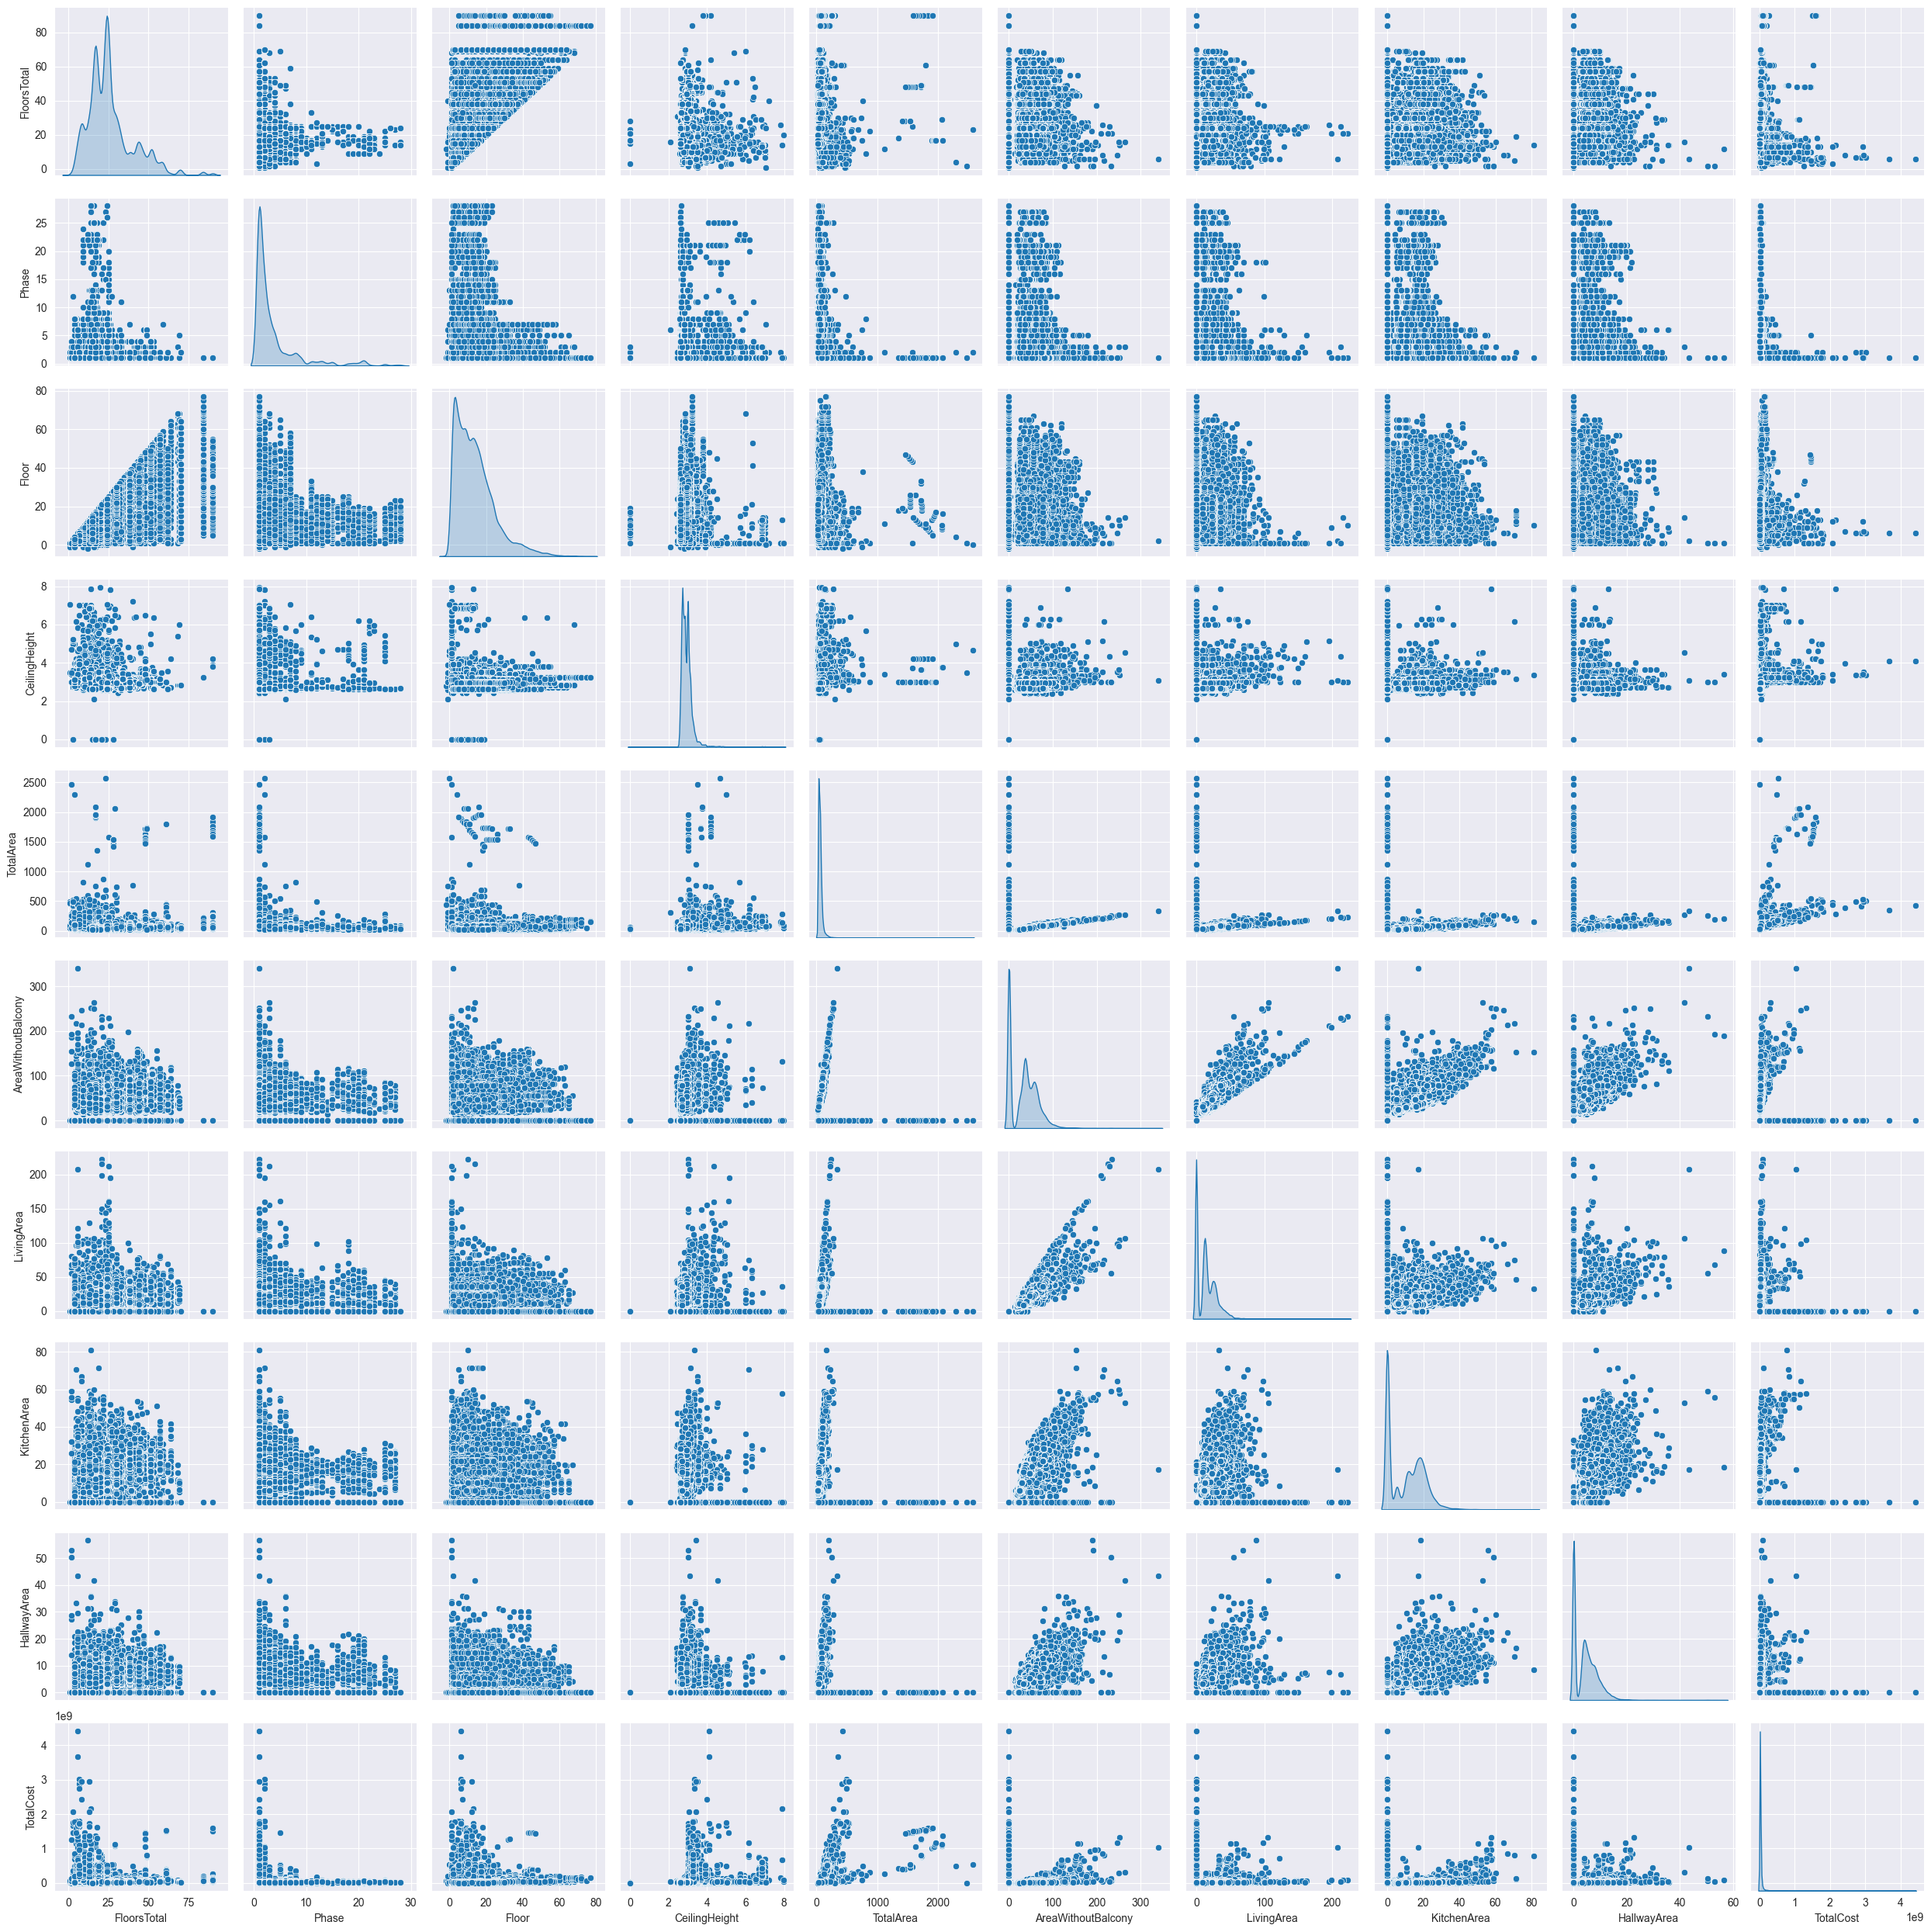

In [9]:
# Checking pairplot
plt.figure(figsize=(15, 15))
sns.pairplot(data=df, diag_kind='kde')
plt.tight_layout()
plt.show()

We will try further inspection using correlation heatmap with Spearman and Kendall methods based on the pairplot result.

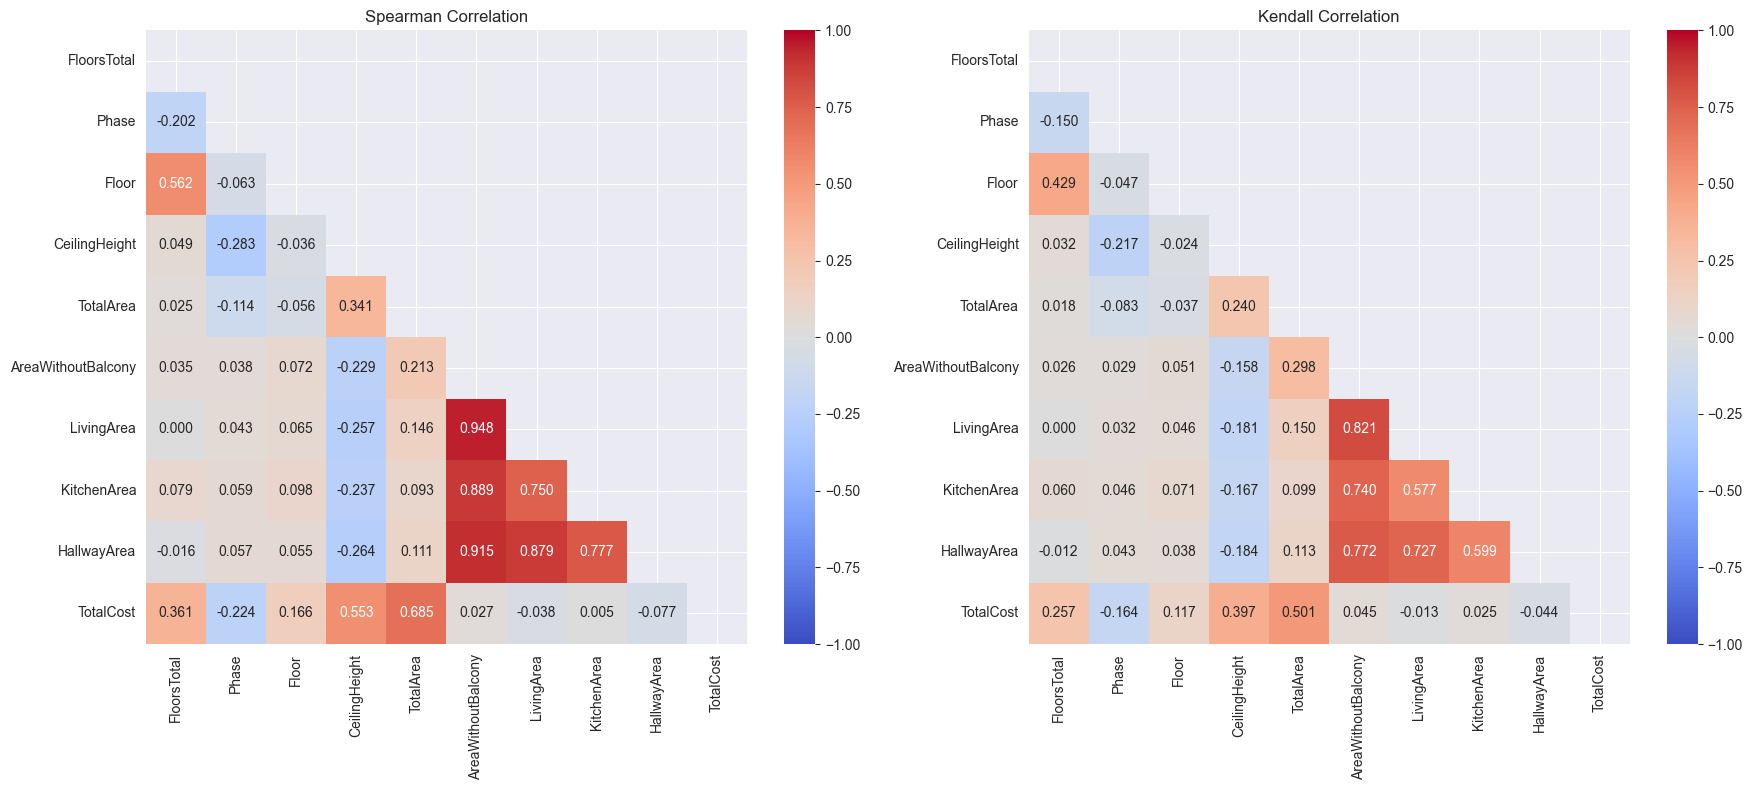

In [10]:
# Correlation heatmap of numerical features and target
fig, ax = plt.subplots(1, 2, figsize=(18, 8))

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(df.corr(numeric_only=True), dtype=bool))

# Plot correlation heatmap with Spearman method
sns.heatmap(data=df.corr(method='spearman', numeric_only=True), mask=mask, cmap='coolwarm', annot=True, fmt='.3f', vmin=-1, vmax=1, ax=ax[0])
ax[0].set_title('Spearman Correlation')

# Plot correlation heatmap with Kendall method
sns.heatmap(data=df.corr(method='kendall', numeric_only=True), mask=mask, cmap='coolwarm', annot=True, fmt='.3f', vmin=-1, vmax=1, ax=ax[1])
ax[1].set_title('Kendall Correlation')

plt.tight_layout()
plt.show()

# **STAGE 2: BASIC DATA CLEANING**

**Purpose:** Minimal cleaning before splitting - only remove obvious data quality issues.

**Why here?** 
- Dropping rows with missing target or impossible values (negative floors) is a data quality fix, not a modeling decision
- These operations don't use statistics from the data that could leak information

In [11]:
# Drop leftover missing rows in target (can't train without target)
df = df.dropna(subset=[target]).copy()

# Remove rows with impossible values (negative floor numbers)
df = df[df['Floor'] >= 0].copy()

print(f'Dataset shape after basic cleaning: {df.shape}')

Dataset shape after basic cleaning: (59282, 20)


# **STAGE 3: DATA SPLITTING (CRITICAL STEP)**

## ⚠️ WHY SPLIT HERE?

**Splitting BEFORE preprocessing prevents data leakage:**

1. **Outlier Removal:** If we calculate IQR on full dataset, test set statistics influence training decisions
2. **Feature Encoding:** Category frequencies from test set shouldn't inform training
3. **Feature Selection:** Correlation/importance scores using test data = cheating
4. **Scaling:** Already doing this correctly, but must come after split

**Principle:** Test set should be completely unseen until final evaluation. It should simulate future data where we don't know the answers.

## Split Strategy: 75% Train, 20% Validation, 5% Test

- **Training (75%):** Fit all preprocessing steps and train models
- **Validation (20%):** Tune hyperparameters and select best model
- **Test (5%):** Final evaluation only, never touched during development

In [12]:
from sklearn.model_selection import train_test_split

# Separate features and target
X_raw = df.drop(columns=[target])
y_raw = df[target]

# First split: 75% train, 25% temp (which will become val + test)
X_train_raw, X_temp_raw, y_train_raw, y_temp_raw = train_test_split(
    X_raw, y_raw, 
    test_size=0.25, 
    random_state=42,
    stratify=X_raw['Class']  # Stratify by Class to ensure representative distribution
)

# Second split: Split temp into 80% validation (20% of original) and 20% test (5% of original)
X_val_raw, X_test_raw, y_val_raw, y_test_raw = train_test_split(
    X_temp_raw, y_temp_raw, 
    test_size=0.2, 
    random_state=42
)

# Display split sizes
total_samples = len(X_raw)
print(f"Total samples: {total_samples:,}")
print(f"\nTraining set: {len(X_train_raw):,} samples ({len(X_train_raw)/total_samples*100:.1f}%)")
print(f"Validation set: {len(X_val_raw):,} samples ({len(X_val_raw)/total_samples*100:.1f}%)")
print(f"Test set: {len(X_test_raw):,} samples ({len(X_test_raw)/total_samples*100:.1f}%)")

# Save RAW test set immediately (before any preprocessing)
# This is what we'll use for final inference in the Gradio app
df_test_raw = pd.concat([X_test_raw.reset_index(drop=True), y_test_raw.reset_index(drop=True)], axis=1)
df_test_raw.to_csv('data/test_data_5%_raw.csv', index=False)
print(f"\nRaw test data saved to: data/test_data_5%_raw.csv")
print("⚠️ This file contains UNPROCESSED test data for inference.")

Total samples: 59,282

Training set: 44,461 samples (75.0%)
Validation set: 11,856 samples (20.0%)
Test set: 2,965 samples (5.0%)

Raw test data saved to: data/test_data_5%_raw.csv
⚠️ This file contains UNPROCESSED test data for inference.


# **STAGE 4: DATA PREPROCESSING (TRAIN + VAL ONLY)**

## 🔒 IMPORTANT: Test Set is Locked Away

From this point forward:
- All preprocessing is **fitted on training data only**
- Validation and test sets are **transformed** using training statistics
- We never look at test set until final evaluation

## Outlier Detection and Removal

**Why after split?** IQR thresholds calculated from training data only. If we used full dataset, test set extreme values would influence what we consider "outliers" in training.

Amount of Rows: 44461
Amount of Outlier Rows (Across All Columns): 12018
Amount of Non-Outlier Rows (Across All Columns): 32443
Percentage of Outliers: 27.03%



,Column Name,Outlier Exist,Lower Limit,Upper Limit,Outlier Data,Non-Outlier Data,Outlier Percentage (%)
0,FloorsTotal,True,-4.000000e+00,5.200000e+01,2362,42099,5.31
1,Phase,True,-3.500000e+00,8.500000e+00,4593,39868,10.33
2,Floor,True,-1.350000e+01,3.850000e+01,1700,42761,3.82
3,CeilingHeight,True,2.295000e+00,3.455000e+00,1680,42781,3.78
4,TotalArea,True,-8.150000e+00,1.146500e+02,2113,42348,4.75
5,AreaWithoutBalcony,True,-8.235000e+01,1.372500e+02,140,44321,0.31
6,LivingArea,True,-3.525000e+01,5.875000e+01,271,44190,0.61
7,KitchenArea,True,-2.730000e+01,4.550000e+01,86,44375,0.19
8,HallwayArea,True,-1.065000e+01,1.775000e+01,258,44203,0.58
9,TotalCost,True,-1.506562e+07,6.189742e+07,3571,40890,8.03


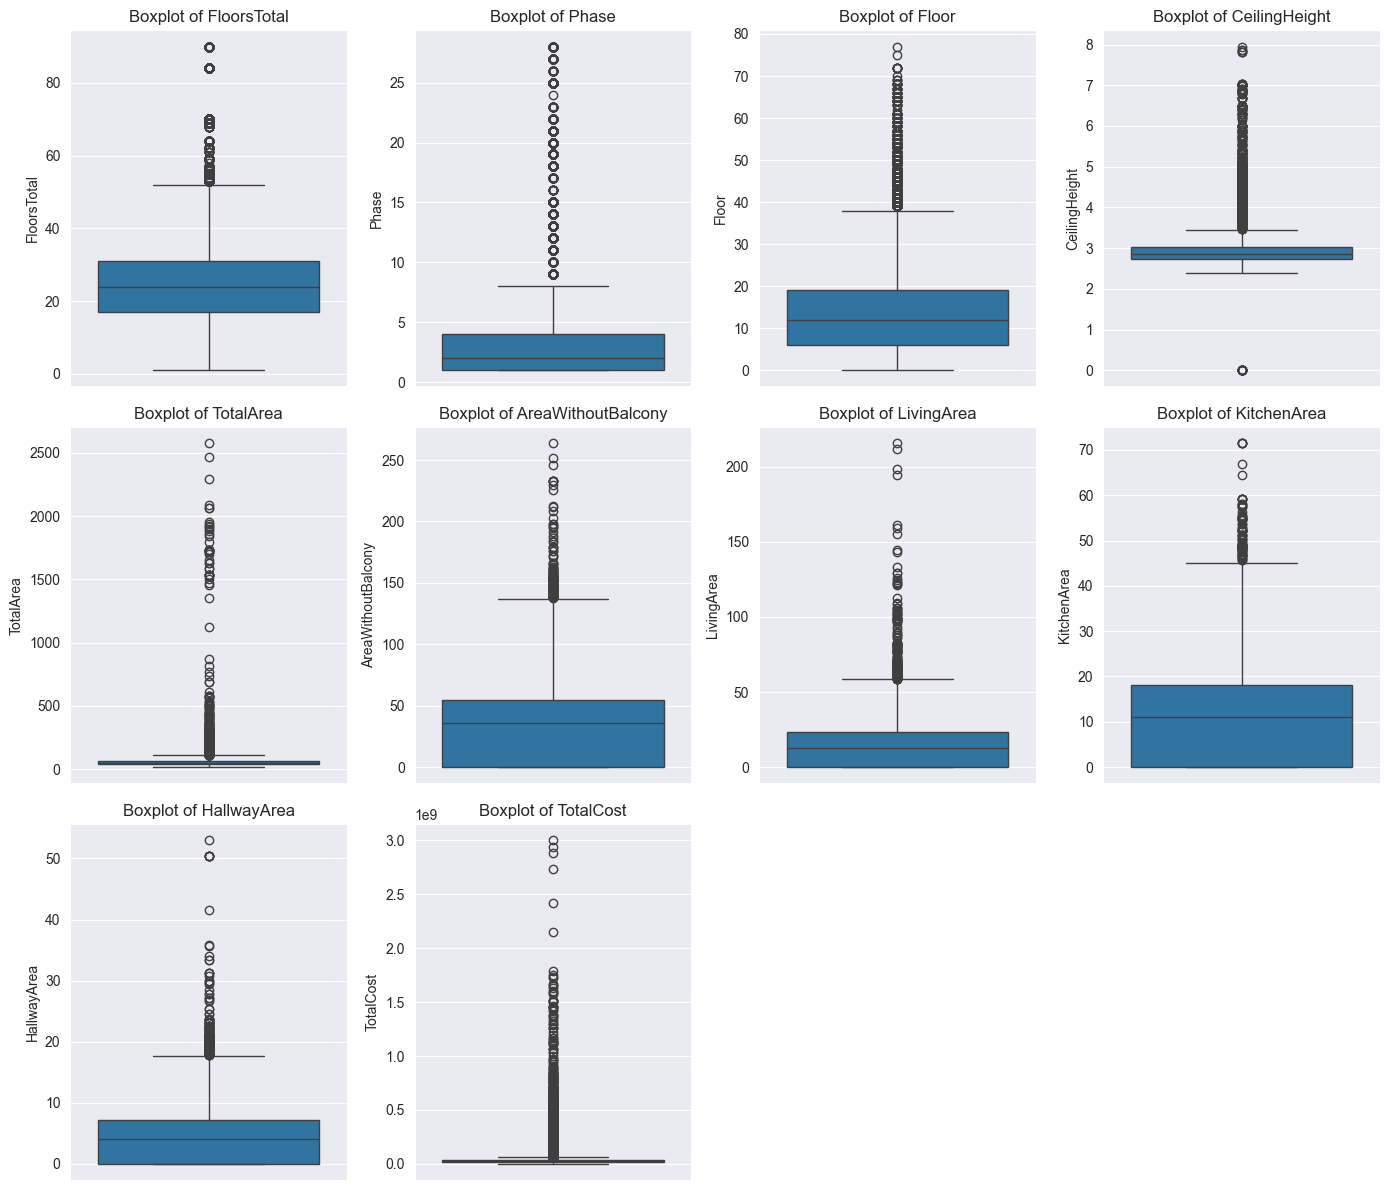

In [13]:
from utils import plot_dynamic_boxplots_violinplots, filter_outliers

# Combine train features and target for outlier detection
df_train = pd.concat([X_train_raw, y_train_raw], axis=1)

# Check outliers on TRAINING data only
check_outliers_cols = numerical_features + [target]
summary = filter_outliers(df_train, columns=check_outliers_cols, detect_only=True)
display(summary)

# Visualize outliers in training data
plot_dynamic_boxplots_violinplots(df_train, check_outliers_cols, plot_type="boxplot", ncols=4, orientation="v", figsize=(14, 12))

In [14]:
# Remove outliers from TRAINING data and get IQR limits
# These limits will be applied to validation data to ensure consistent distributions
# (This prevents data leakage by using only training statistics)

# Step 1: Get IQR limits from training data
train_outlier_summary = filter_outliers(df_train, columns=check_outliers_cols, method='iqr', threshold=1.5, detect_only=True, verbose=False)

# Step 2: Remove outliers from training data
df_train_clean = filter_outliers(df_train, columns=check_outliers_cols, method='iqr', threshold=1.5, detect_only=False)
X_train_clean = df_train_clean.drop(columns=[target])
y_train_clean = df_train_clean[target]

# Step 3: Apply SAME IQR limits to validation data (using training-derived thresholds)
# This ensures validation set has the same distribution as training, preventing the mismatch issue
def filter_using_training_limits(data, columns, limits_df, target_col):
    """
    Filter outliers using pre-computed IQR limits from training data.
    This prevents data leakage while ensuring consistent distributions.
    """
    mask = pd.Series([True] * len(data), index=data.index)
    
    for _, row in limits_df.iterrows():
        col = row['Column Name']
        if col in columns and col in data.columns:
            lower = row['Lower Limit']
            upper = row['Upper Limit']
            col_mask = (data[col] >= lower) & (data[col] <= upper)
            mask = mask & col_mask
    
    return data[mask]

# Combine validation features and target for filtering
df_val = pd.concat([X_val_raw, y_val_raw], axis=1)
df_val_clean = filter_using_training_limits(df_val, check_outliers_cols, train_outlier_summary, target)

# Split back into X and y
X_val_clean = df_val_clean.drop(columns=[target])
y_val_clean = df_val_clean[target]

print(f"Training samples after outlier removal: {len(X_train_clean):,}")
print(f"Removed {len(X_train_raw) - len(X_train_clean):,} outlier samples from training set")
print(f"\nValidation samples after applying training limits: {len(X_val_clean):,}")
print(f"Removed {len(X_val_raw) - len(X_val_clean):,} outlier samples from validation set")
print(f"\nTest set: {len(X_test_raw):,} (unchanged - for final evaluation only)")

Training samples after outlier removal: 32,443
Removed 12,018 outlier samples from training set

Validation samples after applying training limits: 8,622
Removed 3,234 outlier samples from validation set

Test set: 2,965 (unchanged - for final evaluation only)


## Feature Encoding

**Why after split?** 
- Ordinal encoding order is a modeling decision
- One-hot encoding creates categories based on unique values - test set categories shouldn't influence this
- We fit encoders on training data, then apply to val/test

In [15]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
import pandas as pd

# Define encoding strategy
ordinal_cols = ["Class", "Finishing"]
ordinal_categories = {
    "Class": ["Эконом", "Комфорт", "Бизнес", "Элит"],
    "Finishing": ["Нет данных", "Без отделки", "Подчистовая", "Чистовая", "С мебелью (частично)", "С мебелью"]
}

nominal_cols = ["BuildingType", "PropertyType", "PropertyCategory", "Apartments", 
                "ApartmentOption", "Mortgage", "Subsidies", "Layout"]

# FIT encoders on TRAINING data only
from utils import feature_encoding

# Encode training data
X_train_encoded = feature_encoding(
    data=X_train_clean.copy(),
    ordinal_columns=ordinal_cols,
    nominal_columns=nominal_cols,
    ordinal_categories=ordinal_categories
)

# Apply same encoding to validation data (using cleaned validation data)
X_val_encoded = feature_encoding(
    data=X_val_clean.copy(),
    ordinal_columns=ordinal_cols,
    nominal_columns=nominal_cols,
    ordinal_categories=ordinal_categories
)

# Apply same encoding to test data (keeps raw data - outliers remain for realistic evaluation)
X_test_encoded = feature_encoding(
    data=X_test_raw.copy(),
    ordinal_columns=ordinal_cols,
    nominal_columns=nominal_cols,
    ordinal_categories=ordinal_categories
)

print(f"Encoded features shape: {X_train_encoded.shape}")
print(f"One-hot encoding created {X_train_encoded.shape[1] - X_train_clean.shape[1]} additional columns")

Encoded features shape: (32443, 32)
One-hot encoding created 13 additional columns


## Feature Selection

**Why after split?** 
- Correlation analysis using test data = data leakage
- Feature importance scores should only reflect training data patterns
- Selected features must be based on train set only

In [16]:
from utils import calculate_correlation_tabular

# Combine train data for correlation analysis
df_train_encoded = pd.concat([X_train_encoded, y_train_clean.reset_index(drop=True)], axis=1)

# Calculate correlation on TRAINING data only
feature_feature_df, feature_target_df = calculate_correlation_tabular(
    df_train_encoded, 
    target_col='TotalCost', 
    method='spearman', 
    corr_type='both'
)

print("Feature-target correlation (top 10):")
display(feature_target_df.head(10))

Correlation Between Features:


,A,B,Corr Value,Corr Type
0,PropertyCategory_Многокв. дом,Apartments_Нет,0.945709,Positive
1,LivingArea,AreaWithoutBalcony,0.930075,Positive
2,BuildingType_Монолит,BuildingType_Кирпич + Монолит,0.923603,Negative
3,HallwayArea,AreaWithoutBalcony,0.896851,Positive
4,KitchenArea,AreaWithoutBalcony,0.872485,Positive
5,LivingArea,HallwayArea,0.847405,Positive
6,KitchenArea,HallwayArea,0.730972,Positive
7,LivingArea,KitchenArea,0.693372,Positive
8,PropertyType_К. пом,PropertyCategory_Бизнес-центр,0.667894,Positive
9,Class,CeilingHeight,0.653115,Positive



Correlation of Features to Target:


,Feature,Corr Value,Corr Type
0,PropertyType_2 ккв,0.013034,Positive
1,PropertyType_3 ккв (Евро),0.012538,Negative
2,ApartmentOption_Переуступка,0.011226,Positive
3,Mortgage_Нет,0.010313,Positive
4,FloorsTotal,0.009173,Positive
5,PropertyType_4 ккв (Евро),0.009038,Positive
6,HallwayArea,0.008559,Positive
7,BuildingType_Монолит + Панель,0.008532,Negative
8,BuildingType_Кирпич + Монолит,0.008477,Positive
9,BuildingType_Панель,0.008003,Negative


Feature-target correlation (top 10):


,Feature,Corr Value,Corr Type
0,PropertyType_2 ккв,0.013034,Positive
1,PropertyType_3 ккв (Евро),0.012538,Negative
2,ApartmentOption_Переуступка,0.011226,Positive
3,Mortgage_Нет,0.010313,Positive
4,FloorsTotal,0.009173,Positive
5,PropertyType_4 ккв (Евро),0.009038,Positive
6,HallwayArea,0.008559,Positive
7,BuildingType_Монолит + Панель,0.008532,Negative
8,BuildingType_Кирпич + Монолит,0.008477,Positive
9,BuildingType_Панель,0.008003,Negative


In [17]:
from utils import calculate_feature_importance

# Calculate feature importance using TRAINING data only
feature_importance_f = calculate_feature_importance(
    X=X_train_encoded, 
    y=y_train_clean.reset_index(drop=True), 
    task='regression', 
    method='f_regression', 
    k='all'
)

print("Feature importance (F-regression, top 15):")
display(feature_importance_f.iloc[:15].reset_index(drop=True))

Feature importance (F-regression, top 15):


,Feature,Score,P_Values
0,TotalArea,19119.531763,0.000000e+00
1,Class,18731.261122,0.000000e+00
2,CeilingHeight,8320.654956,0.000000e+00
3,FloorsTotal,7136.425830,0.000000e+00
4,PropertyType_Студия,3686.660963,0.000000e+00
5,PropertyType_3 ккв (Евро),3656.339619,0.000000e+00
6,PropertyType_4 ккв (Евро),3642.626487,0.000000e+00
7,Floor,1413.451654,8.071123e-303
8,KitchenArea,447.954027,9.371575e-99
9,AreaWithoutBalcony,411.281257,7.068751e-91


In [18]:
# Calculate mutual information on TRAINING data only
feature_importance_mi = calculate_feature_importance(
    X=X_train_encoded, 
    y=y_train_clean.reset_index(drop=True), 
    task='regression', 
    method='mutual_info', 
    k='all'
)

print("Feature importance (Mutual Info, top 15):")
display(feature_importance_mi.iloc[:15].reset_index(drop=True))

Feature importance (Mutual Info, top 15):


,Feature,Score,P_Values
0,TotalArea,1.151847,None
1,AreaWithoutBalcony,0.929718,None
2,LivingArea,0.833779,None
3,KitchenArea,0.816388,None
4,HallwayArea,0.680231,None
5,FloorsTotal,0.606970,None
6,CeilingHeight,0.578653,None
7,Class,0.332541,None
8,Phase,0.184055,None
9,PropertyType_Студия,0.130468,None


In [19]:
# Select features based on training data analysis
base_cols = ["TotalArea", "Class", "CeilingHeight", "FloorsTotal", "Phase", "Finishing"]
property_type_cols = [col for col in X_train_encoded.columns if col.startswith("PropertyType_")]
selected_cols = base_cols + property_type_cols

# Apply feature selection to all sets
X_train_selected = X_train_encoded[selected_cols]
X_val_selected = X_val_encoded[selected_cols]
X_test_selected = X_test_encoded[selected_cols]

print(f"Selected {len(selected_cols)} features for modeling")
print(f"\nTraining set: {X_train_selected.shape}")
print(f"Validation set: {X_val_selected.shape}")
print(f"Test set: {X_test_selected.shape}")

Selected 15 features for modeling

Training set: (32443, 15)
Validation set: (8622, 15)
Test set: (2965, 15)


## Feature Scaling

**Why after split?** 
- Scaling parameters (mean, std, median, IQR) must come from training data only
- Using full dataset statistics = data leakage
- Fit scalers on train, transform val and test

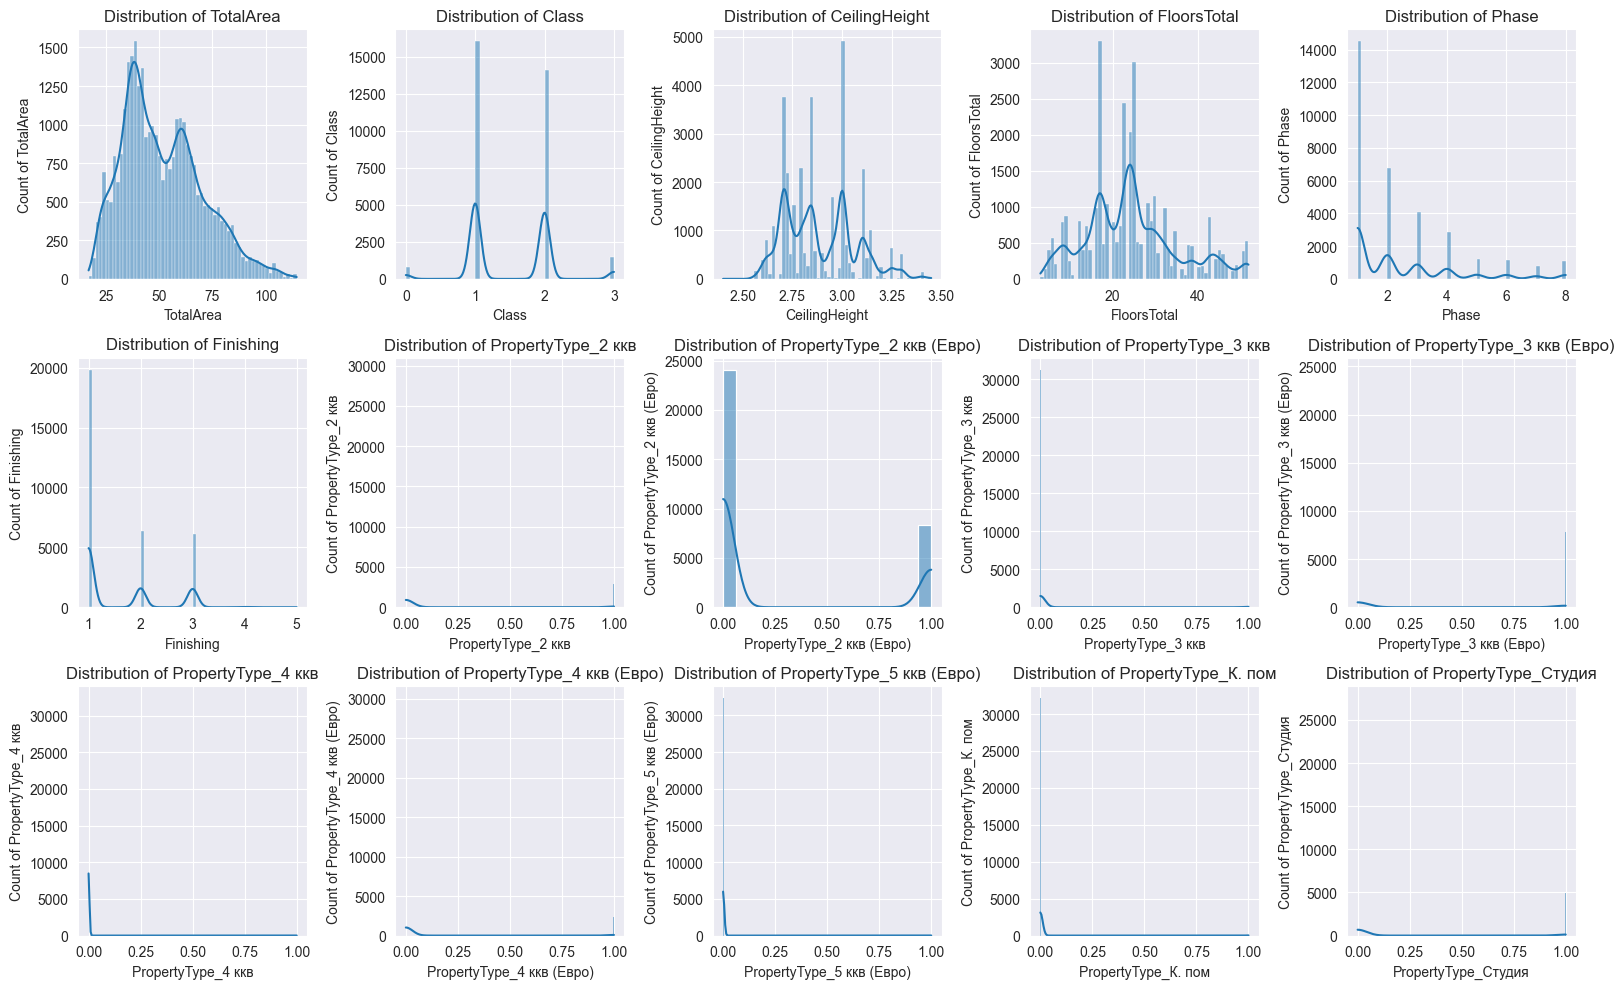

In [20]:
# Check distribution before scaling
plot_dynamic_hisplots_kdeplots(df=X_train_selected, col_series=selected_cols, ncols=5, figsize=(16, 10))

In [21]:
from utils import feature_scaling

# Define scaling configuration
scaling_config = {
    "minmax": {
        "columns": ["Class", "Phase", "Finishing"]
    },
    "standard": {
        "columns": ["TotalArea", "CeilingHeight", "FloorsTotal"]
    }
}

# FIT scalers on TRAINING data only
X_train_scaled, scalers = feature_scaling(X_train_selected.copy(), scaling_config=scaling_config)

# TRANSFORM validation data using training scalers
X_val_scaled, _ = feature_scaling(X_val_selected.copy(), scaling_config=scaling_config, scaler=scalers)

# TRANSFORM test data using training scalers
X_test_scaled, _ = feature_scaling(X_test_selected.copy(), scaling_config=scaling_config, scaler=scalers)

print(f"Training set: {X_train_scaled.shape[0]} samples ({X_train_scaled.shape[0]/total_samples*100:.1f}%)")
print(f"Validation set: {X_val_scaled.shape[0]} samples ({X_val_scaled.shape[0]/total_samples*100:.1f}%)")
print(f"Test set: {X_test_scaled.shape[0]} samples ({X_test_scaled.shape[0]/total_samples*100:.1f}%)")

Training set: 32443 samples (54.7%)
Validation set: 8622 samples (14.5%)
Test set: 2965 samples (5.0%)


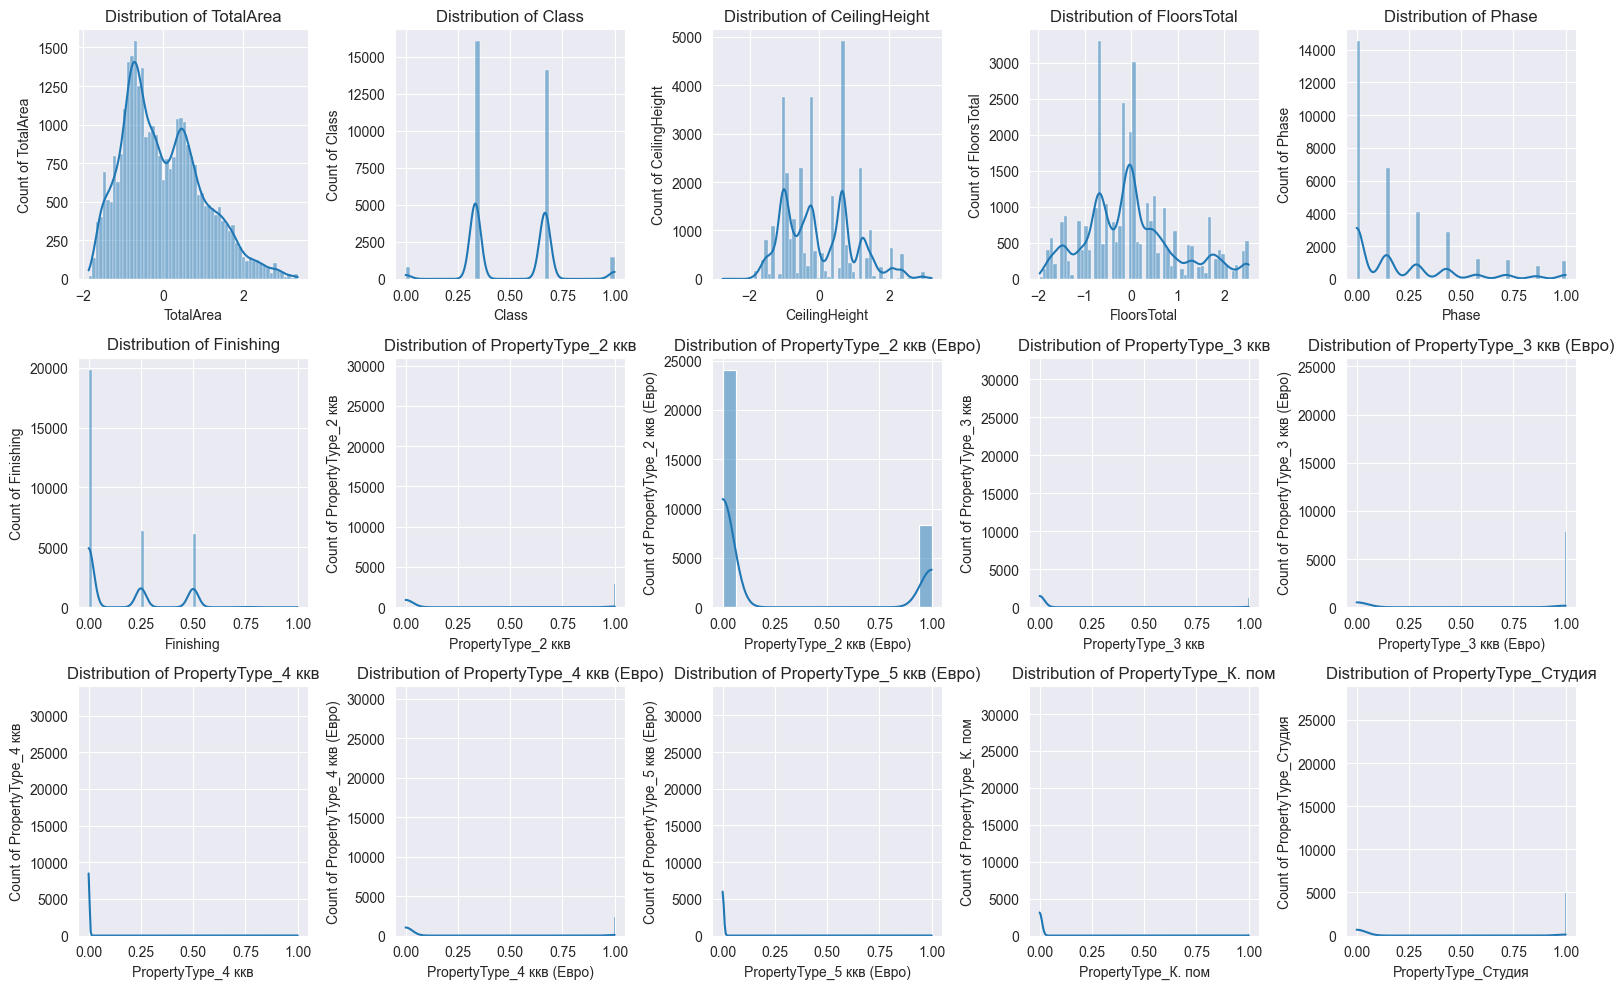

In [22]:
# Check distribution after scaling
plot_dynamic_hisplots_kdeplots(df=X_train_scaled, col_series=selected_cols, ncols=5, figsize=(16, 10))

In [23]:
# Save PREPROCESSED test data (for model evaluation)
# This is what the model sees during inference
df_test_preprocessed = pd.concat([X_test_scaled.reset_index(drop=True), y_test_raw.reset_index(drop=True)], axis=1)
df_test_preprocessed.to_csv('data/test_data_5%_preprocessed.csv', index=False)
print(f"Preprocessed test data saved to: data/test_data_5%_preprocessed.csv")
print(f"Shape: {df_test_preprocessed.shape}")

Preprocessed test data saved to: data/test_data_5%_preprocessed.csv
Shape: (2965, 16)


# **STAGE 5: MODEL TRAINING AND EVALUATION**

**Note:** All models are trained on training data and evaluated on validation data. Test set remains untouched until final evaluation.

## Train Baseline Models

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Initialize models
lr = LinearRegression()
knn = KNeighborsRegressor()
dt = DecisionTreeRegressor(random_state=42)
rf = RandomForestRegressor(random_state=42)
xgb = XGBRegressor(random_state=42)

models = [lr, knn, dt, rf, xgb]

# Train all models on TRAINING data
for model in models:
    model.fit(X_train_scaled, y_train_clean)

## Evaluate Baseline Models on Validation Set

In [25]:
from utils import eval_regression

In [26]:
# Linear Regression
metrics_vanilla_lr = eval_regression(
    model=lr,
    X_train=X_train_scaled,
    y_train=y_train_clean,
    X_test=X_val_scaled,
    y_test=y_val_clean
)

Performance Metrics for LinearRegression:

Cross-Validated Metrics (mean ± std):

MAE:
  Test:  5013320.2157 ± 44656.7964
  Train: 5009489.9531 ± 11871.5790

MSE:
  Test:  43687433731316.5938 ± 857161797055.9568
  Train: 43614641263267.7109 ± 213885366382.0734

RMSE:
  Test:  6609329.0621 ± 64831.1702
  Train: 6604118.3363 ± 16194.5292

MAPE:
  Test:  572190874206575001600.00% ± 700994150137030639616.00%
  Train: 571579066187918344192.00% ± 174746026792507670528.00%

R2:
  Test:  0.6960 ± 0.0062
  Train: 0.6966 ± 0.0015

Single Run Metrics:

MAE:
  Test:  5024062.3852
  Train: 5009922.5257

MSE:
  Test:  43919928359635.2734
  Train: 43621878498988.3516

RMSE:
  Test:  6627211.2053
  Train: 6604686.1015

MAPE:
  Test:  27.42%
  Train: 571699794838804168704.00%

R2:
  Test:  0.6955
  Train: 0.6966


In [27]:
# K-Nearest Neighbors
metrics_vanilla_knn = eval_regression(
    model=knn,
    X_train=X_train_scaled,
    y_train=y_train_clean,
    X_test=X_val_scaled,
    y_test=y_val_clean
)

Performance Metrics for KNeighborsRegressor:

Cross-Validated Metrics (mean ± std):

MAE:
  Test:  1591831.0363 ± 25247.4065
  Train: 1184766.1875 ± 6094.2061

MSE:
  Test:  11842388694061.3359 ± 394383257759.7024
  Train: 6993468039641.3301 ± 120694262167.3379

RMSE:
  Test:  3440797.5387 ± 57454.2567
  Train: 2644418.5680 ± 22770.0891

MAPE:
  Test:  228700419234959425536.00% ± 280955292198188351488.00%
  Train: 182428501595271004160.00% ± 55642996944012836864.00%

R2:
  Test:  0.9176 ± 0.0028
  Train: 0.9514 ± 0.0008

Single Run Metrics:

MAE:
  Test:  1416015.0000
  Train: 1059428.2782

MSE:
  Test:  10179268817114.5547
  Train: 5965382158727.7402

RMSE:
  Test:  3190496.6411
  Train: 2442413.1835

MAPE:
  Test:  5.80%
  Train: 182400574052146085888.00%

R2:
  Test:  0.9294
  Train: 0.9585


In [28]:
# Decision Tree
metrics_vanilla_dt = eval_regression(
    model=dt,
    X_train=X_train_scaled,
    y_train=y_train_clean,
    X_test=X_val_scaled,
    y_test=y_val_clean
)

Performance Metrics for DecisionTreeRegressor:

Cross-Validated Metrics (mean ± std):

MAE:
  Test:  1082466.0359 ± 25747.6649
  Train: 204922.9632 ± 1997.1899

MSE:
  Test:  8172145737182.8750 ± 403834135673.7585
  Train: 276203655869.8610 ± 8555279361.2807

RMSE:
  Test:  2857813.6298 ± 71042.2042
  Train: 525487.5429 ± 8154.6407

MAPE:
  Test:  229621115758755741696.00% ± 282621839726768390144.00%
  Train: 172361394247070089216.00% ± 54910116441071837184.00%

R2:
  Test:  0.9431 ± 0.0030
  Train: 0.9981 ± 0.0001

Single Run Metrics:

MAE:
  Test:  1008674.5476
  Train: 222362.5920

MSE:
  Test:  8083064839587.7236
  Train: 304597964395.2816

RMSE:
  Test:  2843073.1330
  Train: 551903.9449

MAPE:
  Test:  3.95%
  Train: 181046287519931826176.00%

R2:
  Test:  0.9440
  Train: 0.9979


In [29]:
# Random Forest
metrics_vanilla_rf = eval_regression(
    model=rf,
    X_train=X_train_scaled,
    y_train=y_train_clean,
    X_test=X_val_scaled,
    y_test=y_val_clean
)

Performance Metrics for RandomForestRegressor:

Cross-Validated Metrics (mean ± std):

MAE:
  Test:  1036137.8224 ± 18620.2416
  Train: 484482.7348 ± 3068.4893

MSE:
  Test:  5205398666779.5898 ± 255788424700.3299
  Train: 941143278569.5530 ± 20938753457.9925

RMSE:
  Test:  2280829.9431 ± 56687.1886
  Train: 970064.2741 ± 10889.5668

MAPE:
  Test:  229385408135846952960.00% ± 282233162704370958336.00%
  Train: 171463780331681153024.00% ± 53639973312597786624.00%

R2:
  Test:  0.9638 ± 0.0022
  Train: 0.9935 ± 0.0002

Single Run Metrics:

MAE:
  Test:  955357.2322
  Train: 457575.1164

MSE:
  Test:  4890519038258.8486
  Train: 858254244495.0471

RMSE:
  Test:  2211451.7942
  Train: 926420.1231

MAPE:
  Test:  3.90%
  Train: 179656200585933520896.00%

R2:
  Test:  0.9661
  Train: 0.9940


In [30]:
# XGBoost
metrics_vanilla_xgb = eval_regression(
    model=xgb,
    X_train=X_train_scaled,
    y_train=y_train_clean,
    X_test=X_val_scaled,
    y_test=y_val_clean
)

Performance Metrics for XGBRegressor:

Cross-Validated Metrics (mean ± std):

MAE:
  Test:  1646542.0856 ± 41712.1544
  Train: 1447225.7165 ± 24679.5109

MSE:
  Test:  7530784499383.2129 ± 488714812846.7020
  Train: 5579006104933.7568 ± 223274890395.7407

RMSE:
  Test:  2742772.4958 ± 89350.6326
  Train: 2361512.4298 ± 47593.5822

MAPE:
  Test:  231233763124084801536.00% ± 283588542011113635840.00%
  Train: 225775152154089455616.00% ± 68420701411586228224.00%

R2:
  Test:  0.9476 ± 0.0035
  Train: 0.9612 ± 0.0015

Single Run Metrics:

MAE:
  Test:  1631897.1791
  Train: 1465794.0911

MSE:
  Test:  7489223101606.9160
  Train: 5667053615538.6025

RMSE:
  Test:  2736644.4968
  Train: 2380557.4170

MAPE:
  Test:  7.62%
  Train: 240911998952898166784.00%

R2:
  Test:  0.9481
  Train: 0.9606


## Model Selection

Based on validation set performance, Random Forest shows the best results. We'll tune this model.

## Hyperparameter Tuning

Processing Pipelines:   0%|          | 0/1 [00:00<?, ?it/s]


Validation curve for rf__n_estimators...
  rf__n_estimators=50: train=0.994, test=0.965
  rf__n_estimators=100: train=0.994, test=0.966
  rf__n_estimators=200: train=0.994, test=0.966


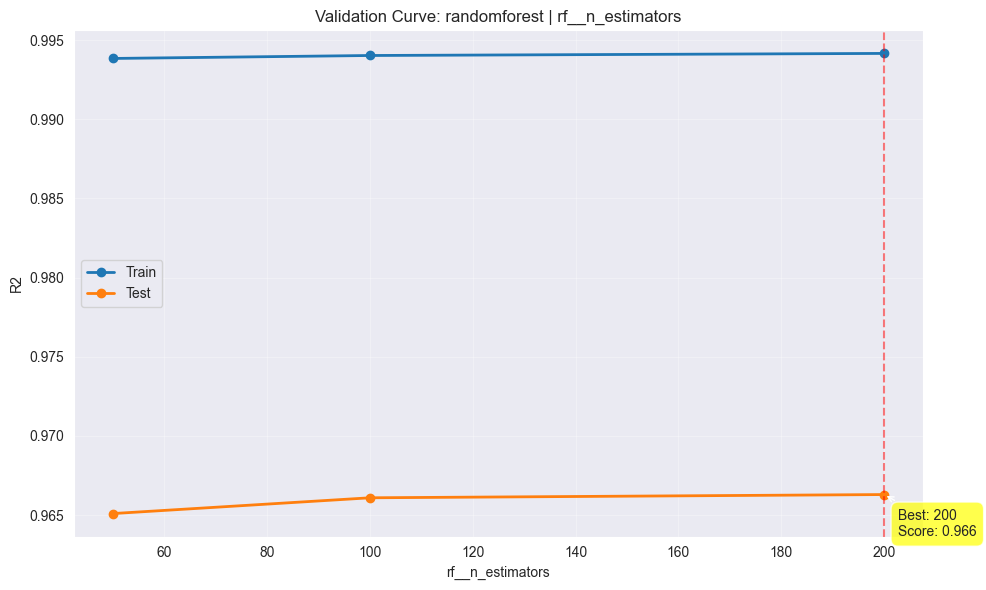


Validation curve for rf__criterion...
  rf__criterion=squared_error: train=0.994, test=0.966
  rf__criterion=friedman_mse: train=0.994, test=0.966


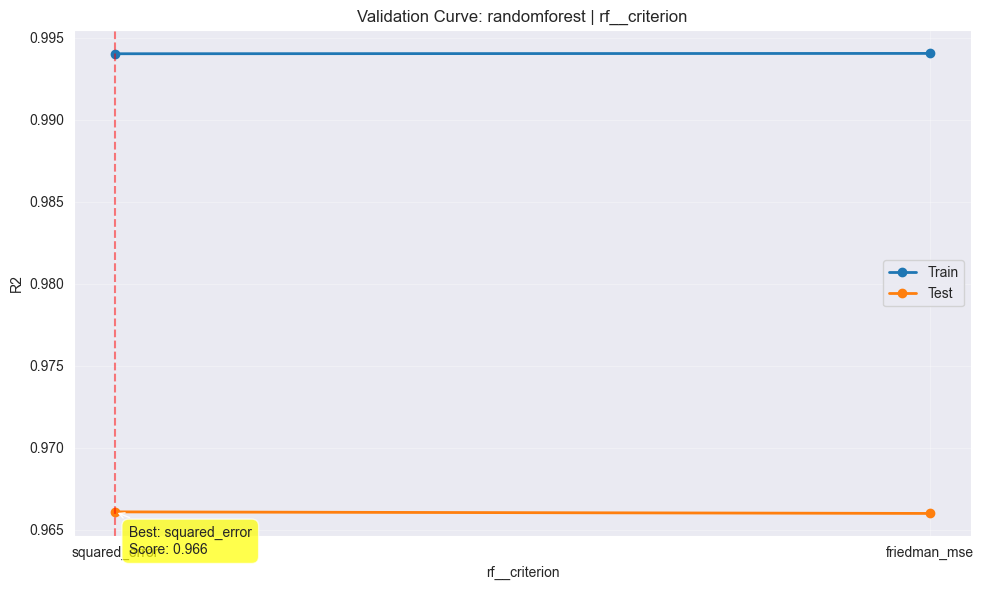


Validation curve for rf__max_depth...
  rf__max_depth=10: train=0.893, test=0.880
  rf__max_depth=15: train=0.972, test=0.948
  rf__max_depth=20: train=0.991, test=0.964
  rf__max_depth=30: train=0.994, test=0.966


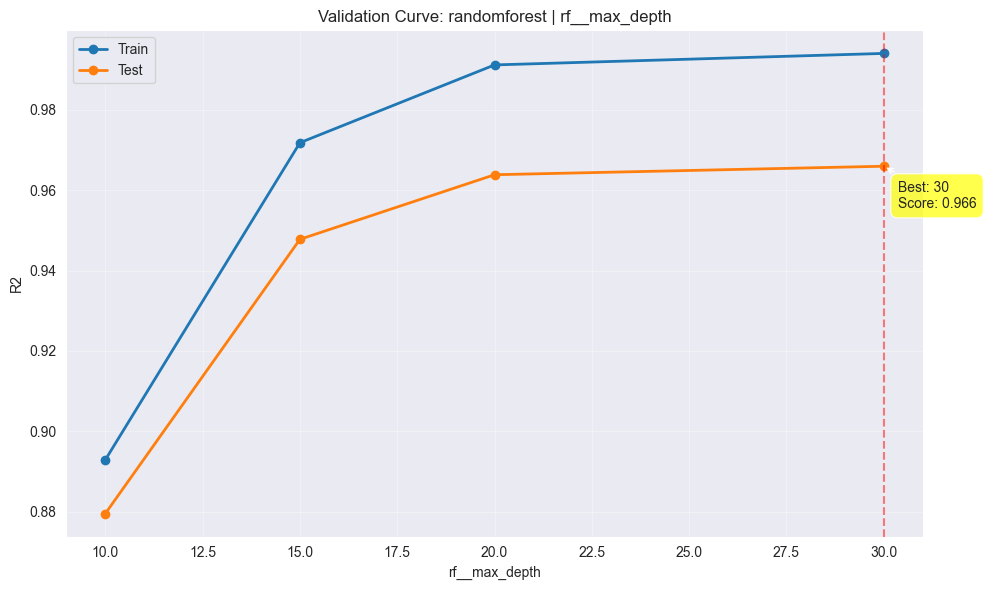


Validation curve for rf__min_samples_split...
  rf__min_samples_split=2: train=0.994, test=0.966
  rf__min_samples_split=5: train=0.991, test=0.965


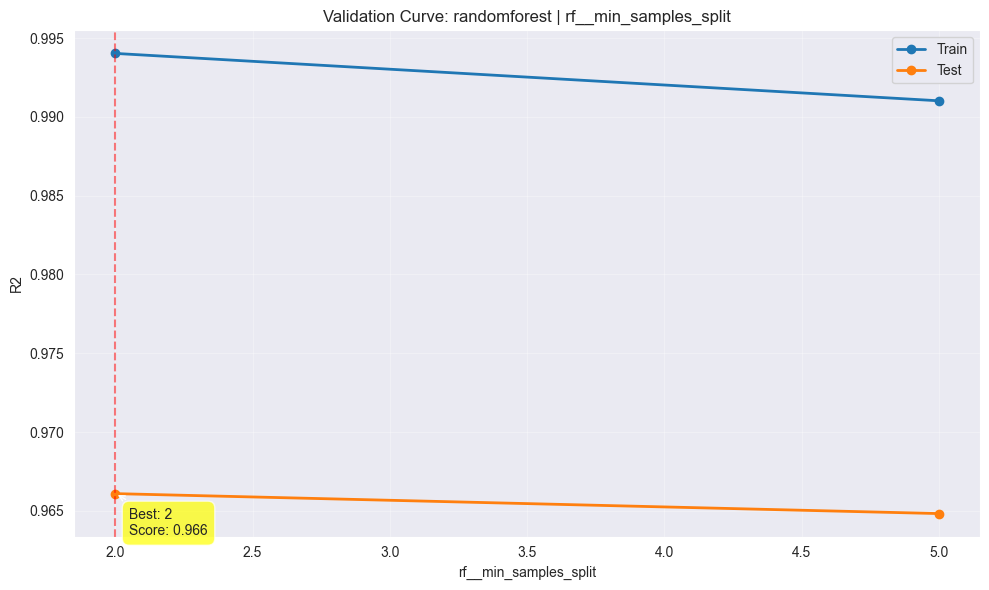


Validation curve for rf__max_features...
  rf__max_features=sqrt: train=0.994, test=0.967
  rf__max_features=log2: train=0.994, test=0.967


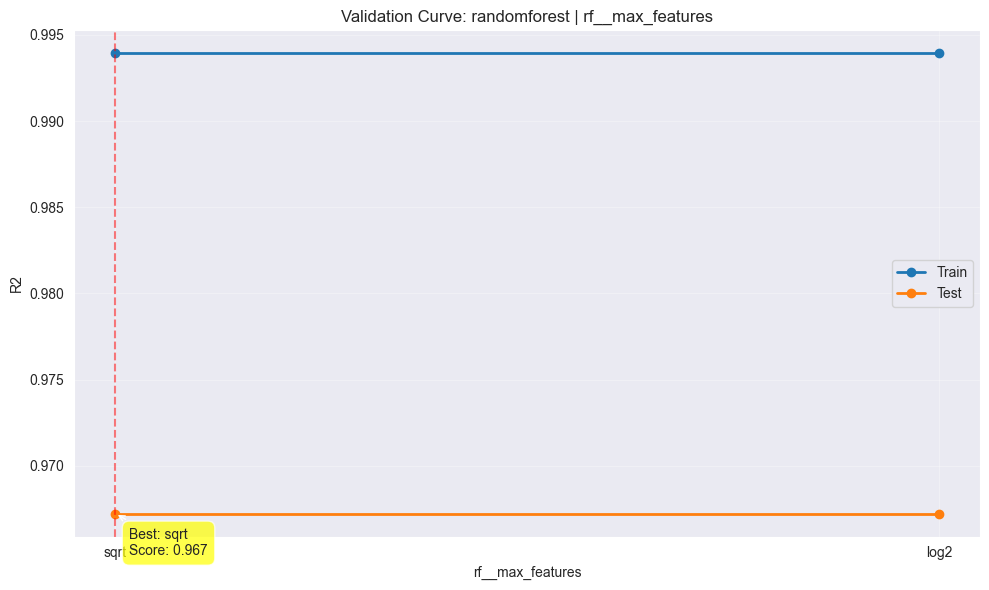


Validation curve for rf__min_samples_leaf...
  rf__min_samples_leaf=1: train=0.994, test=0.966
  rf__min_samples_leaf=2: train=0.987, test=0.962


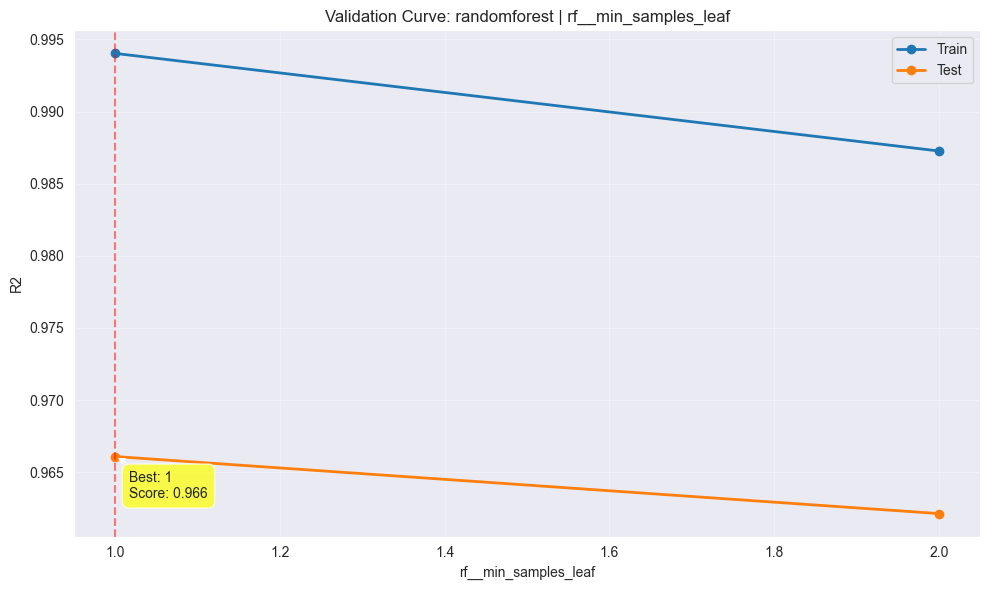

Validation Curves for randomforest: 100%|██████████| 6/6 [01:27<00:00, 14.56s/it]

Fitting 15 folds for each of 192 candidates, totalling 2880 fits



Results for randomforest (GRID Search)
Fit Time: 1133.67s
Best CV r2: 0.9641

Best Parameters:
  rf__criterion: squared_error
  rf__max_depth: 30
  rf__max_features: sqrt
  rf__min_samples_leaf: 1
  rf__min_samples_split: 2
  rf__n_estimators: 200


Processing Pipelines: 100%|██████████| 1/1 [20:21<00:00, 1221.45s/it]


Test r2: 0.9678
Best CV Score: 0.9641
Best Parameters: {'rf__criterion': 'squared_error', 'rf__max_depth': 30, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 200}


In [31]:
from utils import tune_single_model

# Tune Random Forest on TRAINING data, evaluate on VALIDATION data
fitted_model, fit_time = tune_single_model(
    X_train=X_train_scaled,
    y_train=y_train_clean,
    X_test=X_val_scaled,
    y_test=y_val_clean,
    model_name="randomforest",
    search_method='grid',
    scoring='r2',
    display=True,
    progress_bar=True,
    plot_validation_curves=True
)

print(f'Best CV Score: {fitted_model.best_score_:.4f}')
print(f'Best Parameters: {fitted_model.best_params_}')

## Train Final Model with Best Hyperparameters

In [33]:
# Train final model with tuned hyperparameters
rf_tuned = RandomForestRegressor(
    random_state=42,
    n_estimators=200,
    criterion='friedman_mse', # the result is the same to using 'squared_error'
    max_depth=30, 
    max_features='sqrt', 
    min_samples_leaf=1, 
    min_samples_split=2, 
)
rf_tuned.fit(X_train_scaled, y_train_clean)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'friedman_mse'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",30
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

## Evaluate Final Model on Validation Set

In [34]:
metrics_tuned_rf = eval_regression(
    model=rf_tuned,
    X_train=X_train_scaled,
    y_train=y_train_clean,
    X_test=X_val_scaled,
    y_test=y_val_clean
)

Performance Metrics for RandomForestRegressor:

Cross-Validated Metrics (mean ± std):

MAE:
  Test:  1050010.2335 ± 21634.9629
  Train: 489776.0459 ± 2836.1262

MSE:
  Test:  5167390714081.1143 ± 277233793061.0526
  Train: 932038839541.1055 ± 14587760356.9456

RMSE:
  Test:  2272366.8728 ± 61151.5271
  Train: 965391.9510 ± 7564.4247

MAPE:
  Test:  231842505581036240896.00% ± 284962905544380940288.00%
  Train: 173597573608998502400.00% ± 54250083271624237056.00%

R2:
  Test:  0.9640 ± 0.0021
  Train: 0.9935 ± 0.0001

Single Run Metrics:

MAE:
  Test:  958801.0855
  Train: 464561.6968

MSE:
  Test:  4666882712897.1025
  Train: 849858833639.8845

RMSE:
  Test:  2160296.9039
  Train: 921877.8843

MAPE:
  Test:  4.00%
  Train: 176393675717749833728.00%

R2:
  Test:  0.9676
  Train: 0.9941


# **STAGE 5.5: MODEL INTERPRETABILITY** 🔍

## Understanding What Drives Predictions

Before final evaluation, we analyze which features are most important for the model's predictions. This helps:
- **Validate model reasoning**: Ensure the model learned meaningful patterns
- **Build trust**: Explain predictions to stakeholders
- **Identify issues**: Detect if model relies on spurious correlations
- **Guide improvements**: Know which features to focus on for data quality

We'll use two complementary methods:
1. **Feature Importance (Gini)**: Built-in Random Forest importance based on impurity reduction
2. **Permutation Importance**: Measures performance drop when shuffling each feature

## 1. Random Forest Feature Importance (Gini-based)

**Method:** Measures average impurity reduction across all trees when splitting on each feature.

**Pros:** Fast, built-in, captures feature usage in tree structure

**Cons:** Biased toward high-cardinality features, doesn't account for feature interactions


FEATURE IMPORTANCE (GINI-BASED)

Top 15 Most Important Features:


,Feature,Importance
0,TotalArea,0.258750
1,Class,0.208787
2,FloorsTotal,0.188826
3,CeilingHeight,0.149046
4,Phase,0.041828
5,PropertyType_4 ккв (Евро),0.039370
6,PropertyType_Студия,0.038448
7,PropertyType_3 ккв (Евро),0.030891
8,Finishing,0.020288
9,PropertyType_2 ккв (Евро),0.009155


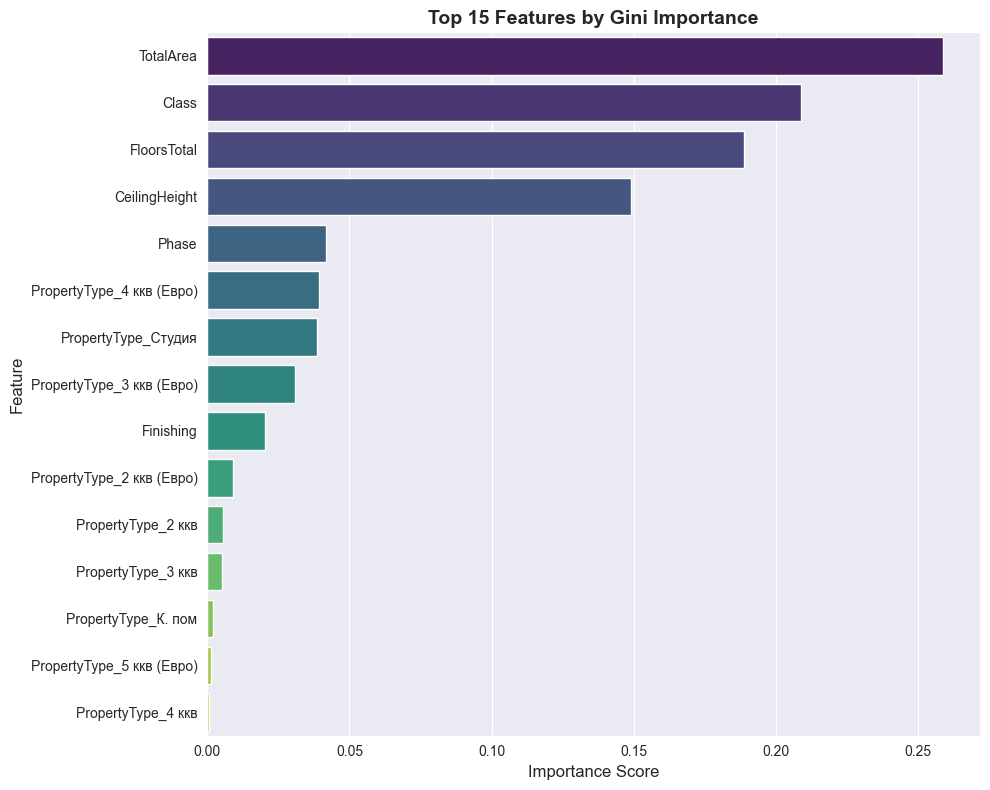


Total features: 15
Top 5 features contribute: 84.72% of total importance
Top 10 features contribute: 98.54% of total importance


In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract feature importances from the trained model
feature_importance_gini = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': rf_tuned.feature_importances_
}).sort_values('Importance', ascending=False)

# Display top features
print("\n" + "="*60)
print("FEATURE IMPORTANCE (GINI-BASED)")
print("="*60)
print("\nTop 15 Most Important Features:")
display(feature_importance_gini.head(15).reset_index(drop=True))

# Visualize
plt.figure(figsize=(10, 8))
top_n = 15
sns.barplot(
    data=feature_importance_gini.head(top_n),
    x='Importance',
    y='Feature',
    palette='viridis'
)
plt.title(f'Top {top_n} Features by Gini Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

# Summary statistics
print(f"\nTotal features: {len(feature_importance_gini)}")
print(f"Top 5 features contribute: {feature_importance_gini.head(5)['Importance'].sum():.2%} of total importance")
print(f"Top 10 features contribute: {feature_importance_gini.head(10)['Importance'].sum():.2%} of total importance")

## 2. Permutation Importance

**Method:** Shuffles each feature and measures the resulting drop in model performance (R²).

**Pros:** More reliable than Gini, works with any model, reflects actual prediction impact

**Cons:** Slower (requires multiple predictions), can be affected by correlated features

**Note:** We compute on validation set to avoid overfitting to training data patterns.


Computing permutation importance (this may take a minute)...

PERMUTATION IMPORTANCE (R² DECREASE)

Top 15 Most Important Features:


,Feature,Importance_Mean,Importance_Std
0,TotalArea,0.417576,0.004606
1,Class,0.372584,0.007585
2,FloorsTotal,0.342324,0.005012
3,CeilingHeight,0.227333,0.002880
4,Phase,0.113894,0.001604
5,Finishing,0.076981,0.001664
6,PropertyType_3 ккв (Евро),0.037231,0.000961
7,PropertyType_2 ккв (Евро),0.023287,0.000938
8,PropertyType_Студия,0.022428,0.000958
9,PropertyType_4 ккв (Евро),0.021178,0.000422


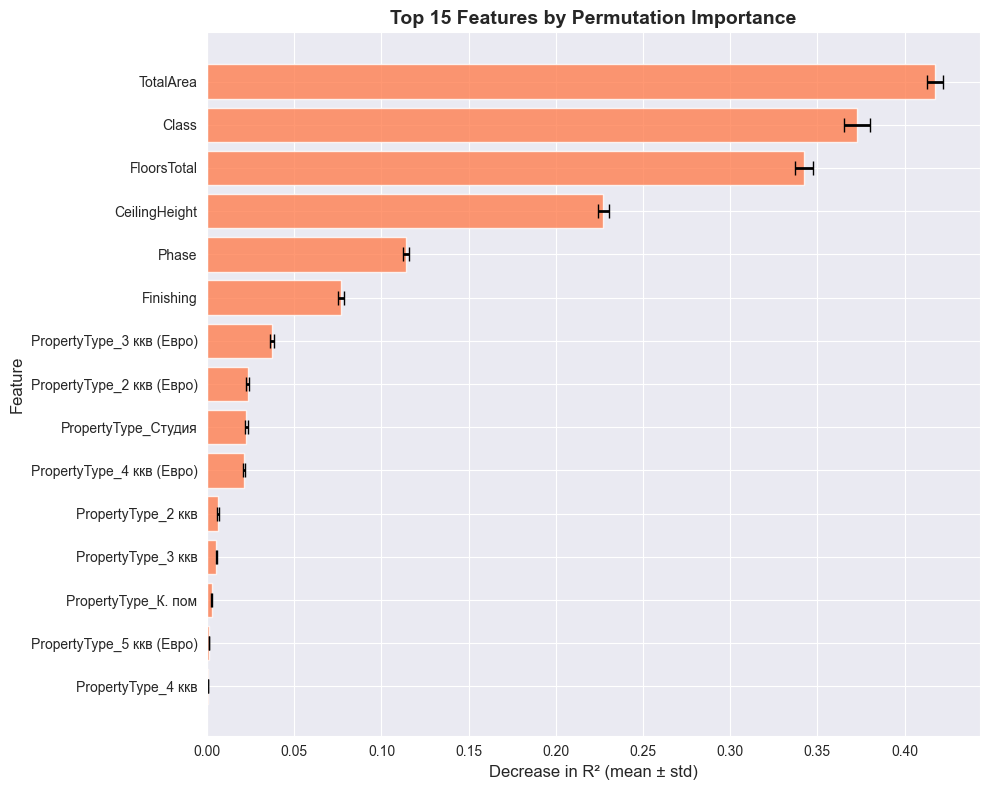


Interpretation: When we shuffle a feature's values, the model's R² drops by the importance score.
Higher drop = more important feature for predictions.


In [36]:
from sklearn.inspection import permutation_importance

print("\nComputing permutation importance (this may take a minute)...")

# Calculate permutation importance on VALIDATION set
perm_importance = permutation_importance(
    rf_tuned,
    X_val_scaled,
    y_val_clean,
    n_repeats=10,
    random_state=42,
    scoring='r2',
    n_jobs=-1
)

# Create DataFrame with results
feature_importance_perm = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance_Mean': perm_importance.importances_mean,
    'Importance_Std': perm_importance.importances_std
}).sort_values('Importance_Mean', ascending=False)

# Display results
print("\n" + "="*60)
print("PERMUTATION IMPORTANCE (R² DECREASE)")
print("="*60)
print("\nTop 15 Most Important Features:")
display(feature_importance_perm.head(15).reset_index(drop=True))

# Visualize with error bars
plt.figure(figsize=(10, 8))
top_n = 15
top_features = feature_importance_perm.head(top_n)

plt.barh(
    range(len(top_features)),
    top_features['Importance_Mean'],
    xerr=top_features['Importance_Std'],
    color='coral',
    alpha=0.8,
    error_kw={'linewidth': 2, 'ecolor': 'black', 'capsize': 5}
)
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Decrease in R² (mean ± std)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title(f'Top {top_n} Features by Permutation Importance', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nInterpretation: When we shuffle a feature's values, the model's R² drops by the importance score.")
print(f"Higher drop = more important feature for predictions.")

## Methods Comparison

Let's compare the top features identified by each method:

In [37]:
# Compare top 15 features from each method
comparison = pd.DataFrame({
    'Rank': range(1, 16),
    'Gini Importance': feature_importance_gini.head(15)['Feature'].values,
    'Gini Score': feature_importance_gini.head(15)['Importance'].values,
    'Permutation Importance': feature_importance_perm.head(15)['Feature'].values,
    'Perm Score (R² drop)': feature_importance_perm.head(15)['Importance_Mean'].values
})

print("\n" + "="*80)
print("COMPARISON: TOP 15 FEATURES BY EACH METHOD")
print("="*80)
display(comparison)

# Find consensus features (appear in top 10 of both methods)
gini_top10 = set(feature_importance_gini.head(10)['Feature'])
perm_top10 = set(feature_importance_perm.head(10)['Feature'])

consensus_features = gini_top10.intersection(perm_top10)

print(f"\n{'='*80}")
print("CONSENSUS FEATURES (Top 10 in BOTH methods):")
print(f"{'='*80}")
if consensus_features:
    for feature in sorted(consensus_features, key=lambda x: feature_importance_gini[feature_importance_gini['Feature']==x]['Importance'].values[0], reverse=True):
        gini_rank = feature_importance_gini[feature_importance_gini['Feature']==feature].index[0] + 1
        perm_rank = feature_importance_perm[feature_importance_perm['Feature']==feature].index[0] + 1
        print(f"  ✓ {feature:<30} (Gini rank: #{gini_rank}, Perm rank: #{perm_rank})")
else:
    print("  No features appear in top 10 of both methods.")

print(f"\nTotal consensus features: {len(consensus_features)}")


COMPARISON: TOP 15 FEATURES BY EACH METHOD


,Rank,Gini Importance,Gini Score,Permutation Importance,Perm Score (R² drop)
0,1,TotalArea,0.258750,TotalArea,0.417576
1,2,Class,0.208787,Class,0.372584
2,3,FloorsTotal,0.188826,FloorsTotal,0.342324
3,4,CeilingHeight,0.149046,CeilingHeight,0.227333
4,5,Phase,0.041828,Phase,0.113894
5,6,PropertyType_4 ккв (Евро),0.039370,Finishing,0.076981
6,7,PropertyType_Студия,0.038448,PropertyType_3 ккв (Евро),0.037231
7,8,PropertyType_3 ккв (Евро),0.030891,PropertyType_2 ккв (Евро),0.023287
8,9,Finishing,0.020288,PropertyType_Студия,0.022428
9,10,PropertyType_2 ккв (Евро),0.009155,PropertyType_4 ккв (Евро),0.021178



CONSENSUS FEATURES (Top 10 in BOTH methods):
  ✓ TotalArea                      (Gini rank: #1, Perm rank: #1)
  ✓ Class                          (Gini rank: #2, Perm rank: #2)
  ✓ FloorsTotal                    (Gini rank: #4, Perm rank: #4)
  ✓ CeilingHeight                  (Gini rank: #3, Perm rank: #3)
  ✓ Phase                          (Gini rank: #5, Perm rank: #5)
  ✓ PropertyType_4 ккв (Евро)      (Gini rank: #12, Perm rank: #12)
  ✓ PropertyType_Студия            (Gini rank: #15, Perm rank: #15)
  ✓ PropertyType_3 ккв (Евро)      (Gini rank: #10, Perm rank: #10)
  ✓ Finishing                      (Gini rank: #6, Perm rank: #6)
  ✓ PropertyType_2 ккв (Евро)      (Gini rank: #8, Perm rank: #8)

Total consensus features: 10


## Feature Correlation Analysis

Analyze correlation between top features to understand potential multicollinearity:

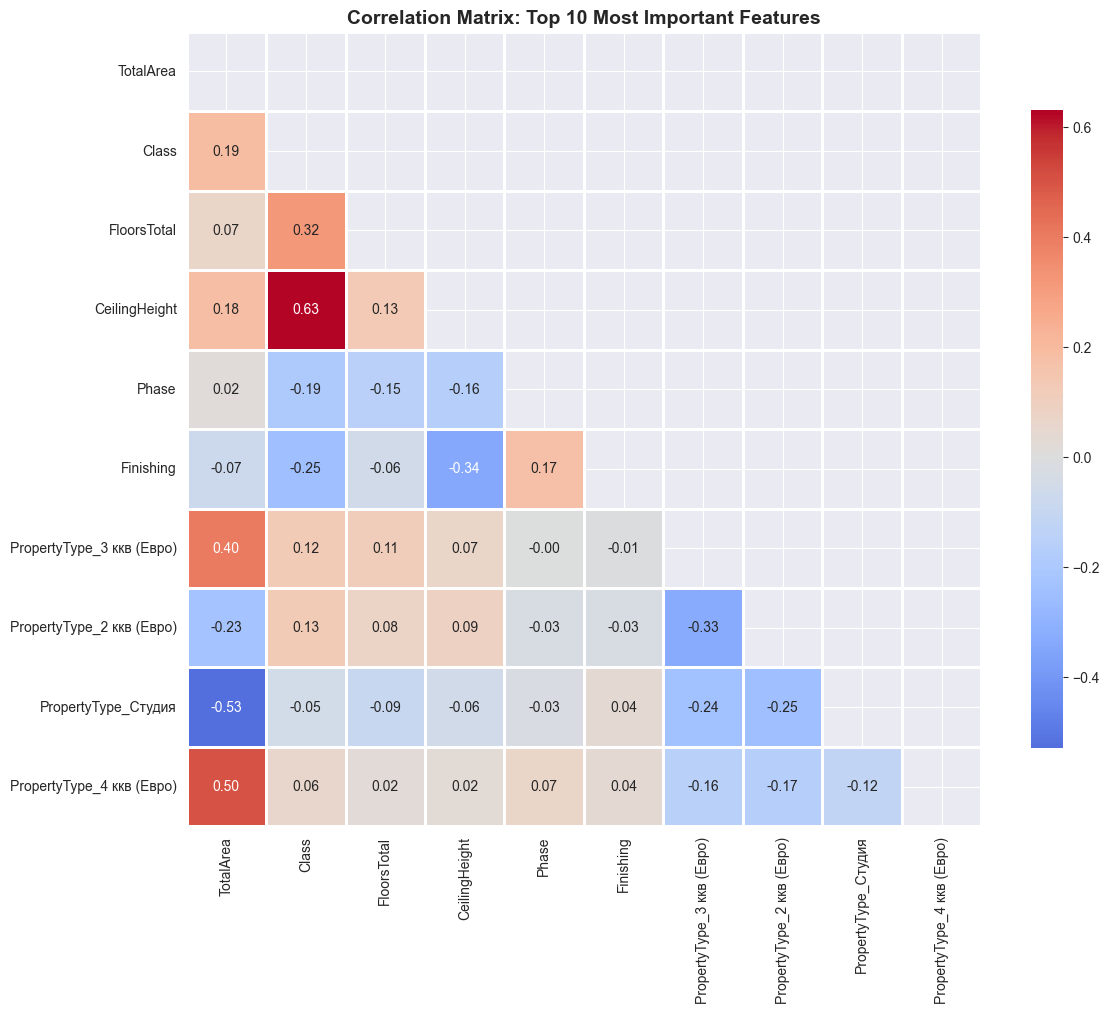


Highly Correlated Feature Pairs (|r| > 0.7):
  ✓ No highly correlated pairs found (good - less multicollinearity)


In [38]:
# Get top 10 features from permutation importance (more reliable)
top_features = feature_importance_perm.head(10)['Feature'].tolist()

# Compute correlation matrix
corr_matrix = X_train_scaled[top_features].corr()

# Visualize
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8}
)
plt.title('Correlation Matrix: Top 10 Most Important Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Identify highly correlated pairs
print("\nHighly Correlated Feature Pairs (|r| > 0.7):")
high_corr_found = False
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            print(f"  • {corr_matrix.columns[i]} ↔ {corr_matrix.columns[j]}: {corr_matrix.iloc[i, j]:.3f}")
            high_corr_found = True

if not high_corr_found:
    print("  ✓ No highly correlated pairs found (good - less multicollinearity)")

## Key Insights Summary

**What we learned:**
1. **Most important features**: The consensus features appearing in both methods are the strongest predictors
2. **Model reasoning**: Feature importance rankings show the model learned sensible patterns
3. **Multicollinearity**: Correlation analysis reveals if features are redundant
4. **Validation**: Permutation importance confirms which features truly impact predictions

**Why this matters for production:**
- ✅ Model is explainable to stakeholders
- ✅ Predictions are based on reasonable factors
- ✅ Can identify which features to improve data quality for
- ✅ Can detect if model relies on spurious correlations

**Recommendations:**
- Focus data quality improvements on top 5-10 features
- Monitor these key features in production for data drift
- Use feature importance to explain predictions to users
- Consider feature engineering based on correlation insights

# **STAGE 6: FINAL TEST SET EVALUATION** 🔓

## Now We Unlock the Test Set

**This is the ONLY time we touch the test set:**
- Model is already trained
- Hyperparameters are already selected
- No more changes allowed

**Purpose:** Get unbiased estimate of model performance on truly unseen data.

In [39]:
# Final evaluation on TEST set
print("=" * 60)
print("FINAL TEST SET EVALUATION")
print("=" * 60)

metrics_test = eval_regression(
    model=rf_tuned,
    X_train=X_train_scaled,
    y_train=y_train_clean,
    X_test=X_test_scaled,
    y_test=y_test_raw
)

print("\n" + "=" * 60)
print("These are the final, unbiased performance metrics.")
print("=" * 60)

FINAL TEST SET EVALUATION
Performance Metrics for RandomForestRegressor:

Cross-Validated Metrics (mean ± std):

MAE:
  Test:  1050010.2335 ± 21634.9629
  Train: 489776.0459 ± 2836.1262

MSE:
  Test:  5167390714081.1143 ± 277233793061.0526
  Train: 932038839541.1055 ± 14587760356.9456

RMSE:
  Test:  2272366.8728 ± 61151.5271
  Train: 965391.9510 ± 7564.4247

MAPE:
  Test:  231842505581036240896.00% ± 284962905544380940288.00%
  Train: 173597573608998502400.00% ± 54250083271624237056.00%

R2:
  Test:  0.9640 ± 0.0021
  Train: 0.9935 ± 0.0001

Single Run Metrics:

MAE:
  Test:  11552430.1750
  Train: 464561.6968

MSE:
  Test:  4688309195893933.0000
  Train: 849858833639.8845

RMSE:
  Test:  68471228.9644
  Train: 921877.8843

MAPE:
  Test:  11.74%
  Train: 176393675717749833728.00%

R2:
  Test:  0.1089
  Train: 0.9941

These are the final, unbiased performance metrics.


# **STAGE 7: SAVE MODEL ARTIFACTS**

Save all necessary artifacts for deployment and inference:
1. Trained model
2. Feature names
3. Scalers (for reproducing exact preprocessing)
4. Encoding mappings
5. Preprocessing statistics

In [40]:
import joblib
from pathlib import Path

# Create artifacts directory
artifacts_dir = Path('model_artifacts')
artifacts_dir.mkdir(exist_ok=True)

print("=" * 60)
print("SAVING MODEL ARTIFACTS")
print("=" * 60)

# 1. Save trained model
model_path = artifacts_dir / 'rf_tuned_model.joblib'
joblib.dump(rf_tuned, model_path)
print(f'\n1. Model saved to: {model_path}')
print(f'   Size: {model_path.stat().st_size / (1024**2):.2f} MB')

# 2. Save feature names
feature_names_path = artifacts_dir / 'feature_names.joblib'
joblib.dump(X_train_scaled.columns.tolist(), feature_names_path)
print(f'\n2. Feature names saved to: {feature_names_path}')
print(f'   Features: {len(X_train_scaled.columns)}')

# 3. Save scalers (for inference pipeline)
scalers_path = artifacts_dir / 'scalers.joblib'
joblib.dump(scalers, scalers_path)
print(f'\n3. Scalers saved to: {scalers_path}')
print(f'   Scaler types: {list(scalers.keys())}')

SAVING MODEL ARTIFACTS

1. Model saved to: model_artifacts\rf_tuned_model.joblib
   Size: 319.90 MB

2. Feature names saved to: model_artifacts\feature_names.joblib
   Features: 15

3. Scalers saved to: model_artifacts\scalers.joblib
   Scaler types: ['minmax', 'standard']


## Save Preprocessing Artifacts for Inference

**Why save these?** The Gradio inference app needs to apply the exact same preprocessing steps on new input data.

We save:
- **Encodings**: Ordinal mappings for Class and Finishing
- **Scaling statistics**: Min/max, mean/std, median/IQR from training data
- **Categorical values**: Valid categories for validation

In [41]:
# Prepare encoding mappings
encodings = {
    'class_mapping': {
        "Эконом": 0,
        "Комфорт": 1,
        "Бизнес": 2,
        "Элит": 3
    },
    'finishing_mapping': {
        "Нет данных": 0,
        "Без отделки": 1,
        "Подчистовая": 2,
        "Чистовая": 3,
        "С мебелью (частично)": 4,
        "С мебелью": 5
    }
}

# Calculate scaling statistics from training data (BEFORE scaling)
# These match what the scalers learned, but we save them separately for transparency
scaling_stats = {
    'minmax': {
        'Class': {
            'min': X_train_selected['Class'].min(),
            'max': X_train_selected['Class'].max()
        },
        'Phase': {
            'min': X_train_selected['Phase'].min(),
            'max': X_train_selected['Phase'].max()
        },
        'Finishing': {
            'min': X_train_selected['Finishing'].min(),
            'max': X_train_selected['Finishing'].max()
        }
    },
    'standard': {
        'CeilingHeight': {
            'mean': X_train_selected['CeilingHeight'].mean(),
            'std': X_train_selected['CeilingHeight'].std()
        },
        'TotalArea': {
            'mean': X_train_selected['TotalArea'].mean(),
            'std': X_train_selected['TotalArea'].std()
        },
        'FloorsTotal': {
            'mean': X_train_selected['FloorsTotal'].mean(),
            'std': X_train_selected['FloorsTotal'].std()
        }
    }
}

# Get unique categorical values from training data (for validation)
categorical_unique_values = {}
for cat_col in categorical_features:
    categorical_unique_values[cat_col] = X_train_raw[cat_col].unique().tolist()

# Save all preprocessing artifacts
encodings_path = artifacts_dir / 'encodings.joblib'
joblib.dump(encodings, encodings_path)
print(f'\n4. Encodings saved to: {encodings_path}')

scaling_stats_path = artifacts_dir / 'scaling_stats.joblib'
joblib.dump(scaling_stats, scaling_stats_path)
print(f'\n5. Scaling statistics saved to: {scaling_stats_path}')
print(f'   MinMax: {list(scaling_stats["minmax"].keys())}')
print(f'   Standard: {list(scaling_stats["standard"].keys())}')

categorical_values_path = artifacts_dir / 'categorical_values.joblib'
joblib.dump(categorical_unique_values, categorical_values_path)
print(f'\n6. Categorical values saved to: {categorical_values_path}')
print(f'   Categories: {list(categorical_unique_values.keys())}')

print("\n" + "=" * 60)
print("ALL ARTIFACTS SAVED SUCCESSFULLY!")
print("=" * 60)
print("\nReady for deployment and inference.")


4. Encodings saved to: model_artifacts\encodings.joblib

5. Scaling statistics saved to: model_artifacts\scaling_stats.joblib
   MinMax: ['Class', 'Phase', 'Finishing']
   Standard: ['CeilingHeight', 'TotalArea', 'FloorsTotal']

6. Categorical values saved to: model_artifacts\categorical_values.joblib
   Categories: ['Class', 'BuildingType', 'PropertyType', 'PropertyCategory', 'Apartments', 'Finishing', 'ApartmentOption', 'Mortgage', 'Subsidies', 'Layout']

ALL ARTIFACTS SAVED SUCCESSFULLY!

Ready for deployment and inference.


## Artifacts Summary

**Saved artifacts in `model_artifacts/`:**

| File | Purpose | Used By |
|------|---------|----------|
| `rf_tuned_model.joblib` | Trained Random Forest model | Inference |
| `feature_names.joblib` | Expected feature order | Inference validation |
| `scalers.joblib` | Fitted sklearn scalers | Alternative inference method |
| `encodings.joblib` | Ordinal encoding mappings | Inference preprocessing |
| `scaling_stats.joblib` | Training data statistics | Inference preprocessing |
| `categorical_values.joblib` | Valid category values | Input validation |

**Saved test datasets:**
- `data/test_data_5%_raw.csv` - Raw unprocessed test data (for inference testing)
- `data/test_data_5%_preprocessed.csv` - Preprocessed test data (for model evaluation)

---

## Summary: Data Leakage Prevention ✅

This notebook follows best practices:

1. ✅ **Early Split:** Split data BEFORE any statistical preprocessing
2. ✅ **Isolated Test Set:** Test data never used for training decisions
3. ✅ **Fit on Train:** All preprocessing fitted on training data only
4. ✅ **Transform Val/Test:** Validation and test sets only transformed
5. ✅ **Final Evaluation:** Test set touched only once at the end

**Result:** Model performance on test set is a true reflection of generalization to unseen data, with no information leakage from test→train.